importing Libraries

In [55]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [56]:
freq=pd.read_csv("E:\\TMP\\data analysis_Python_Excel\\study build project\\insurance\\data\\freMTPL2freq.csv")
sev=pd.read_csv("E:\\TMP\\data analysis_Python_Excel\\study build project\\insurance\\data\\freMTPL2sev.csv")

### 📊 Key Exploratory Data Analysis (EDA) Summary (freq dataset)

* **Target Variable (`ClaimNb`):**
  * Heavily **zero-inflated** and right-skewed.
  * Over $75\%$ of policyholders reported zero claims ($Q_3 = 0$).
  * Empirical statistics: $\text{Mean} = 0.053$, $\text{Max} = 16$.
  * *Modeling Implication:* Requires count-data or compound models (e.g., Poisson, Negative Binomial, or Tweedie regression with XGBoost/LightGBM).

* **Exposure (`Exposure`):**
  * Represents policy duration in years: $\text{Mean} \approx 0.53$ (~6 months), with $Q_3 = 0.99$ (standard annual policy).
  * *Modeling Implication:* Must serve as a modeling **offset** term to model claim frequency per unit of exposure:
    $$\text{Claim Frequency} = \frac{\text{ClaimNb}}{\text{Exposure}}$$

* **Risk & Policyholder Demographics:**
  * **Driver Age (`DrivAge`):** Well-distributed between $18$ and $100$ years ($\text{Mean} \approx 45.5$, $\text{Median} = 44$).
  * **Bonus-Malus (`BonusMalus`):** Heavily concentrated at base scale $50$ ($\ge 50\%$ of observations hold the maximum safety discount).
  * **Vehicle Age (`VehAge`):** Typical median of $6$ years; the maximum of $100$ years indicates potential vintage vehicles or data-entry anomalies requiring validation.

* **Geographic Density (`Density`):**
  * Exhibits extreme positive skewness and variance ($\text{Median} = 393 \text{ vs. } \text{Mean} = 1,792$, ranging from $1$ to $27,000$).
  * *Data Preparation:* Strongly recommended to apply a log transformation ($\log(1 + x)$ via `np.log1p`) prior to feature ingestion.


In [57]:
freq.info()

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   VehPower    678013 non-null  int64  
 4   VehAge      678013 non-null  int64  
 5   DrivAge     678013 non-null  int64  
 6   BonusMalus  678013 non-null  int64  
 7   VehBrand    678013 non-null  str    
 8   VehGas      678013 non-null  str    
 9   Area        678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 62.1 MB


In [58]:
freq.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,6.780130e+05,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000
mean,2.621857e+06,0.053247,0.528750,6.454631,7.044265,45.499122,59.761502,1792.422405
std,1.641783e+06,0.240117,0.364442,2.050906,5.666232,14.137444,15.636658,3958.646564
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157951e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272152e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046274e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


In [59]:
sev.info()

<class 'pandas.DataFrame'>
RangeIndex: 26444 entries, 0 to 26443
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26444 non-null  int64  
 1   ClaimAmount  26444 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 413.3 KB


In [60]:
sev.describe()

,IDpol,ClaimAmount
count,2.644400e+04,2.644400e+04
mean,2.280004e+06,2.265513e+03
std,1.583004e+06,2.937103e+04
min,1.390000e+02,1.000000e+00
25%,1.086381e+06,6.859925e+02
50%,2.133756e+06,1.172000e+03
75%,3.183953e+06,1.212385e+03
max,6.113971e+06,4.075401e+06


Data Cleaning:

1. Find duplicates in dataset

-----
freq dataset shows data relevant to policy. It shows datails and data about vehicles and claims.

sev dataset shows data relavant to claims(cost of claims)

In [61]:
freq.duplicated().sum()

np.int64(0)

In [62]:
sev.duplicated().sum()

np.int64(235)

In [63]:
freq.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region'],
      dtype='str')

---------
EDA
--------




### **Executive EDA Summary: Feature Distributions & Analytical Insights**

1. **Driver Age (`DrivAge`):**
   * **Distribution:** Quasi-bell-shaped with high density concentrated between **30 and 55 years**, tapering off smoothly past 60 with a long tail up to 100.
   * **Portfolio Insight:** The portfolio is dominated by middle-aged drivers. Young drivers (ages 18–25) account for a very small volume, meaning their portfolio risk stems from **elevated per-unit claim frequency**, not total exposure.

2. **Vehicle Age (`VehAge`):**
   * **Distribution:** Heavily right-skewed with a prominent peak near zero ($0\text{–}3$ years) and a steep drop toward a sparse tail ($30\text{–}40+$ years).
   * **Portfolio Insight:** The insured fleet is predominantly modern and relatively new; vintage/aged vehicles represent rare edge cases.

3. **Vehicle Power (`VehPower`):**
   * **Distribution:** Discrete range ($4\text{ to }15$), peaking sharply between **5 and 7**, followed by a stepwise decline.
   * **Portfolio Insight:** The vast majority are standard, low-to-mid power passenger vehicles; high-performance and luxury cars make up a negligible fraction.

4. **Bonus-Malus (`BonusMalus`):**
   * **Distribution:** Severely right-skewed with massive concentration ($>400,000$ policies) pegged at the base level of **50** (maximum safety discount).
   * **Portfolio Insight:** Most policyholders maintain clean driving records. The high-risk tail ($\text{BM} > 150$) is tiny in policy count but drives disproportionately higher loss rates.

5. **Population Density (`Density`):**
   * **Distribution:** Highly right-skewed. The majority reside in low-density rural or suburban zones, with a long tail and a minor density spike around $25,000$ (reflecting dense urban centers like Paris).


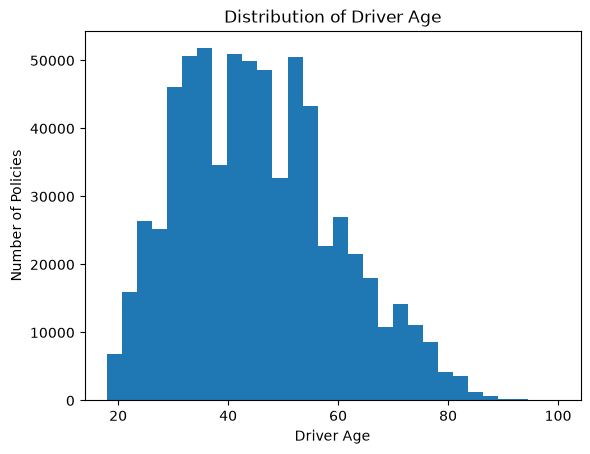

In [64]:
plt.hist(freq["DrivAge"], bins=30)
plt.xlabel("Driver Age")
plt.ylabel("Number of Policies")
plt.title("Distribution of Driver Age")
plt.show()

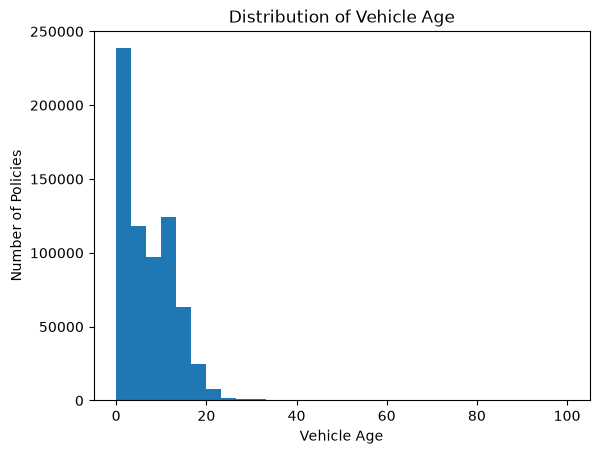

In [65]:
plt.hist(freq["VehAge"], bins=30)
plt.xlabel("Vehicle Age")
plt.ylabel("Number of Policies")
plt.title("Distribution of Vehicle Age")
plt.show()

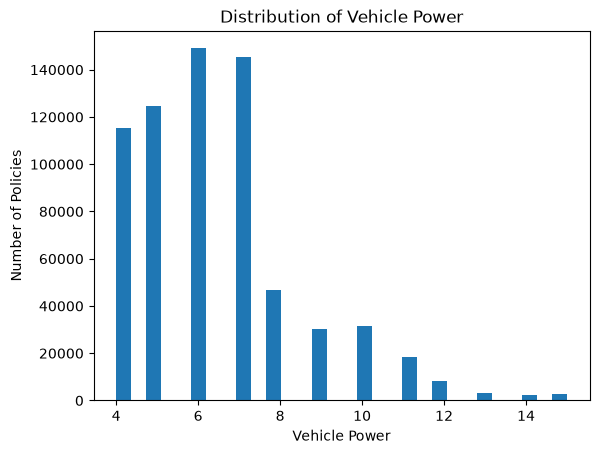

In [66]:
plt.hist(freq["VehPower"], bins=30)
plt.xlabel("Vehicle Power")
plt.ylabel("Number of Policies")
plt.title("Distribution of Vehicle Power")
plt.show()

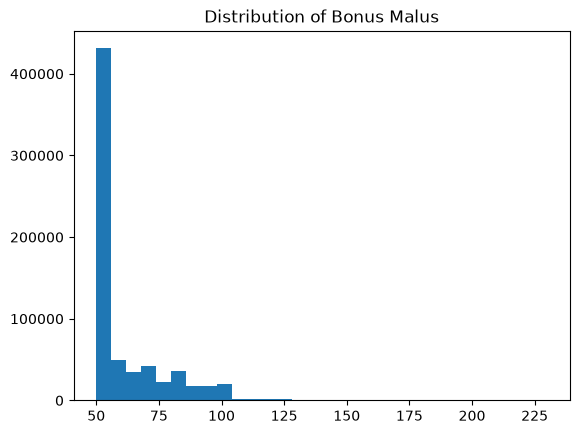

In [67]:
plt.hist(freq["BonusMalus"], bins=30)
# plt.xlabel("Vehicle Power")
# plt.ylabel("Number of Policies")
plt.title("Distribution of Bonus Malus")
plt.show()

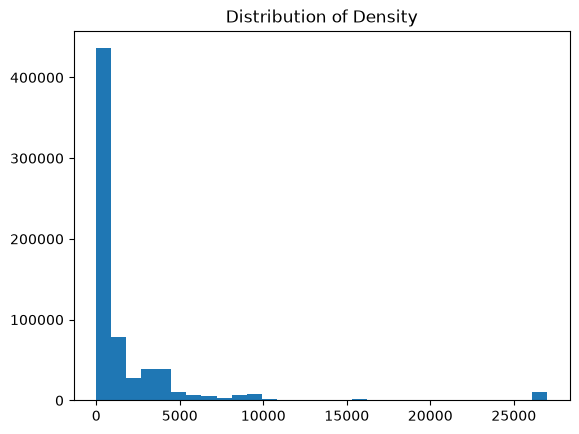

In [68]:
plt.hist(freq["Density"], bins=30)
# plt.xlabel("Vehicle Power")
# plt.ylabel("Number of Policies")
plt.title("Distribution of Density")
plt.show()

-------
KPIs
------

####  Key Takeaways & Mathematical Coherence

* **Claim Frequency ($\approx 10.07\%$):** On average, $0.1007$ claims are incurred per unit of policy exposure.
* **Harmonized Severity ($\approx 1,659.44$):** Evaluates average loss across all registered claims (including zero-cost filings), reducing upward bias and harmonizing the frequency-severity denominator.
* **Pure Premium Consistency:** Aligning the claim base ensures exact mathematical reconciliation into the pure risk premium per unit exposure:

$$\text{Pure Premium} = \text{Claim Frequency} \times \text{Average Severity} = 0.1007 \times 1,659.44 \approx 167.12$$


Claim Frequency = Total Claims / Total Exposure

Meaning Of This KPI : 

به ازای هر واحد Exposure، به‌طور متوسط چند Claim اتفاق افتاده است؟

In [69]:
Total_claims=freq['ClaimNb'].sum()
Total_exposure=freq['Exposure'].sum()

Claim_Frequency=Total_claims/Total_exposure

Claim_Frequency

np.float64(0.10070308464063966)

Average Claim Severity = Total Claim Cost / Number of Claims

Meaning Of This KPI :


به‌طور متوسط، هر خسارت 
(Claim) 
چقدر برای شرکت بیمه هزینه ایجاد کرده است

In [70]:
total_claim_cost = sev["ClaimAmount"].sum()
number_of_claims = freq["ClaimNb"].sum()

avg_severity = total_claim_cost / number_of_claims

avg_severity

np.float64(1659.4431471940613)

Total Claim Cost

Meaning Of This KPI :  

مجموع هزینه هایی که خسارات ایجاد کرده اند. 

In [71]:
total_claim_cost = sev["ClaimAmount"].sum()

total_claim_cost

np.float64(59909216.5)

In [72]:
# frq_sev=pd.merge(freq , sev , how='right', on='IDpol')

In [73]:
# frq_sev[['IDpol','ClaimNb','ClaimAmount']]

In [74]:
# df1=frq_sev.groupby('IDpol').agg(total_claim_cost=('ClaimAmount',"sum"),total_claim_numbers=('ClaimNb','sum')).reset_index()

------------

#### 💡 Architectural Rationale

* **Granularity Alignment ($1:N \rightarrow 1:1$):**
  * `freq` is structured at the **Policy level**, while `sev` is at the individual **Claim level** (a single policy can have multiple claims).
  * Grouping by `IDpol` first prevents row duplication and distortion of total `Exposure` during the merge.

* **Clean Aggregation (`as_index=False` & Named Aggregation):**
  * `as_index=False` retains `IDpol` as a regular column for seamless join syntax.
  * Named aggregation directly produces clean, flat column names without creating messy `MultiIndex` columns.
  * `ClaimCount_Sev` enables audit reconciliation against the reported `ClaimNb`.

* **Preserving Portfolio Integrity (`how="left"`):**
  * A **Left Join** ensures all $678,013$ original policies are preserved (an `inner` join would discard $>95\%$ of non-claimant policies, invalidating risk modeling).
  * Non-claimant rows naturally yield `NaN`, which can immediately be imputed to `0` via `.fillna(0)`.


In [75]:
sev_policy = (
    sev.groupby("IDpol", as_index=False)
       .agg(
           TotalClaimCost=("ClaimAmount", "sum"),
           ClaimCount_Sev=("ClaimAmount", "count")
       )
)

In [76]:
df = freq.merge(
    sev_policy,
    on="IDpol",
    how="left"
)

In [77]:
df

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,TotalClaimCost,ClaimCount_Sev
0,1.0,1,0.10000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,NaN,NaN
1,3.0,1,0.77000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,NaN,NaN
2,5.0,1,0.75000,6,2,52,50,B12,Diesel,B,54,Picardie,NaN,NaN
3,10.0,1,0.09000,7,0,46,50,B12,Diesel,B,76,Aquitaine,NaN,NaN
4,11.0,1,0.84000,7,0,46,50,B12,Diesel,B,76,Aquitaine,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326.0,0,0.00274,4,0,54,50,B12,Regular,E,3317,Provence-Alpes-Cotes-D'Azur,NaN,NaN
678009,6114327.0,0,0.00274,4,0,41,95,B12,Regular,E,9850,Ile-de-France,NaN,NaN
678010,6114328.0,0,0.00274,6,2,45,50,B12,Diesel,D,1323,Rhone-Alpes,NaN,NaN
678011,6114329.0,0,0.00274,4,0,60,50,B12,Regular,B,95,Bourgogne,NaN,NaN


In [78]:
df.isna().sum()

IDpol                  0
ClaimNb                0
Exposure               0
VehPower               0
VehAge                 0
DrivAge                0
BonusMalus             0
VehBrand               0
VehGas                 0
Area                   0
Density                0
Region                 0
TotalClaimCost    653069
ClaimCount_Sev    653069
dtype: int64

-------
KPI 
سطح بیمه نامه 
-------

In [79]:
df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)

In [80]:
df["HasClaim"]

0         1
1         1
2         1
3         1
4         1
         ..
678008    0
678009    0
678010    0
678011    0
678012    0
Name: HasClaim, Length: 678013, dtype: int64

Meaning Of This KPI: 

In [81]:
df["ClaimCostPerExposure"] = (df["TotalClaimCost"] / df["Exposure"])

In [82]:
df["ClaimCostPerExposure"].isnull().value_counts()

ClaimCostPerExposure
True     653069
False     24944
Name: count, dtype: int64

#### Output Interpretation

| Value | Policy Count | Business & Technical Meaning |
| :--- | :--- | :--- |
| **`True` (NaN / Missing)** | **$653,069$** | Non-claimant policies (No matched record in `sev_policy`). |
| **`False` (Populated)** | **$24,944$** | Claimant policies with actual incurred loss costs. |
| **Total Policies** | **$678,013$** | Complete portfolio preserved via Left Join ($653,069 + 24,944$). |

---

####  Critical Actuarial & Data Science Takeaway

* **Element-Wise Arithmetic & `NaN` Propagation:**
  * Because `TotalClaimCost` defaults to `NaN` for non-claimants after the left join, element-wise division ($\frac{\text{NaN}}{\text{Exposure}}$) propagates `NaN` across all $653,069$ non-claimant rows.

* **The Survivor Bias Trap in `.mean()`:**
  * In Pandas, aggregation methods like `.mean()` silently skip `NaN`s by default (`skipna=True`).
  * Computing `.mean()` without imputation evaluates cost strictly across the $24,944$ claimant policies, massively overestimating portfolio risk.


### 📊 Policy-Level Pure Premium (Loss Cost per Unit of Exposure)

For each individual policy, this metric divides the total incurred claim cost by its corresponding exposure (policyholder-years). 

$$\text{ClaimCostPerExposure}_i = \frac{\text{TotalClaimCost}_i}{\text{Exposure}_i}$$

> **Core Concept:** It quantifies: *"How much loss did this specific policy generate for the insurer per unit of covered risk?"*


In [83]:
df["TotalClaimCost"] = df["TotalClaimCost"].fillna(0)
df["ClaimCostPerExposure"] = df["TotalClaimCost"] / df["Exposure"]


In [84]:
df["AvgClaimSeverity"] = np.where(df["ClaimNb"] > 0,df["TotalClaimCost"] / df["ClaimNb"],0)

For each policy, it divides the total claim cost by its **Exposure** (policy-years). In other words, it asks: *"How much loss did this specific policy cost the insurance company per unit of covered risk?"*


------

### ⚖️ مقایسه دو شاخص: `AvgClaimSeverity` در برابر `ClaimCostPerExposure`

این دو شاخص مفهوم کاملاً متفاوتی دارند، زیرا **مخرج کسر** در هرکدام بیانگر بعد متفاوتی از ریسک است:

| بعد مقایسه | `AvgClaimSeverity` | `ClaimCostPerExposure` |
| :--- | :--- | :--- |
| **فرمول محاسباتی** | $\frac{\text{TotalClaimCost}}{\text{ClaimNb}}$ | $\frac{\text{TotalClaimCost}}{\text{Exposure}}$ |
| **مخرج کسر** | **تعداد خسارت** (رویدادها) | **مدت‌زمان پوشش ریسک** (سال-بیمه) |
| **سؤال محوری** | *«هر بار که خسارت رخ داد، به‌طور میانگین چقدر هزینه داشت؟»* | *«به‌ازای هر واحد زمانی که تحت پوشش بود، چقدر هزینه تولید کرد؟»* |
| **حساس به تکرار خسارت؟** | ❌ خیر (میانگین هر رویداد است) | ✅ بله (تکرار خسارت مقدار آن را بالا می‌برد) |
| **حساس به مدت بیمه‌نامه؟** | ❌ خیر | ✅ بله (کاهش مدت پوشش، نرخ را سالانه و بزرگ می‌کند) |

---

#### 📌 یک مثال واقعی از داده‌های پرتفوی:

| `IDpol` | `Exposure` | `ClaimNb` | `TotalClaimCost` | `AvgClaimSeverity` | `ClaimCostPerExposure` |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **$1128173$** | ۱.۰۰ (یک سال کامل) | ۱ | ۱۱.۰۰ | **۱۱.۰۰** | **۱۱.۰۰** |
| **$3063246$** | ۰.۰۹ (~۱ ماه) | ۱ | ۴۸.۵۳ | **۴۸.۵۳** | **۵۳۹.۲۲** |

* **تحلیل مثال:**
  * بیمه‌نامه دوم فقط ۴۸.۵۳ واحد هزینه داشته و `AvgClaimSeverity` آن نیز عدد معقولی است.
  * اما چون این بیمه‌نامه فقط **۰.۰۹ سال** تحت پوشش بوده، وقتی همین خسارت به مدت کوتاه تقسیم می‌شود، مقدار `ClaimCostPerExposure` به **۵۳۹.۲۲** می‌رسد (نزدیک به ۵۰ برابر بیمه‌نامه اول)، در حالی‌که هزینه‌ی واقعی خسارت تنها حدود ۴.۴ برابر بوده است!

---

#### 💡 کاربرد عملی و نتیجه‌گیری:

۱. از **`AvgClaimSeverity`** برای بررسی **شدت خسارت‌ها و توزیع هزینه** استفاده کنید (مستقل از طول عمر بیمه‌نامه، مناسب برای مدل‌سازی شدت با توزیع‌های گاما یا لگ‌نرمال).  
۲. از **`ClaimCostPerExposure`** برای سنجش **نرخ ریسک در واحد زمان و حق‌بیمه فنی (Pure Premium)** استفاده کنید که پایه اصلی نرخ‌گذاری (Pricing) است.

> ⚠️ **هشدار اکچوئری (انحراف ناشی از مخرج کوچک):**  
> بیمه‌نامه‌هایی با Exposure بسیار کوچک (مانند ۰.۰۱ یا ۰.۰۲) می‌توانند مقادیر کاذب بسیار بزرگی تولید کنند. از میانگین‌گیری ساده روی سطرهای این ستون خودداری کنید؛ همواره از فرمول تجمیعی کل پرتفوی ($\frac{\sum \text{TotalClaimCost}}{\sum \text{Exposure}}$) استفاده نمایید.


###  Metric Comparison: `AvgClaimSeverity` vs. `ClaimCostPerExposure`

These two metrics convey fundamentally different concepts because their **denominators** measure distinct dimensions:

| Dimension | `AvgClaimSeverity` | `ClaimCostPerExposure` |
| :--- | :--- | :--- |
| **Formula** | $\frac{\text{TotalClaimCost}}{\text{ClaimNb}}$ | $\frac{\text{TotalClaimCost}}{\text{Exposure}}$ |
| **Denominator** | **Claim Count** (Number of events) | **Risk Exposure** (Policy-years) |
| **Core Question** | *"When a claim occurred, how severe was it on average?"* | *"Per unit of time under coverage, how much loss did this policy generate?"* |
| **Sensitive to Claim Frequency?** | ❌ No (Measures mean cost per event) | ✅ Yes (Repeated claims increase the metric) |
| **Sensitive to Policy Duration?** | ❌ No | ✅ Yes (Shorter exposure inflates the annualized rate) |

---

####  Real-World Dataset Example:

| `IDpol` | `Exposure` | `ClaimNb` | `TotalClaimCost` | `AvgClaimSeverity` | `ClaimCostPerExposure` |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **$1128173$** | $1.00$ (Full year) | $1$ | $\$11.00$ | **$\$11.00$** | **$\$11.00$** |
| **$3063246$** | $0.09$ (~$1$ month) | $1$ | $\$48.53$ | **$\$48.53$** | **$\$539.22$** |

* **Analysis of the Example:**
  * Policy `3063246` generated a modest absolute claim of $\$48.53$, and its `AvgClaimSeverity` reflects that moderate cost ($\$48.53$).
  * However, because it was exposed for only **$0.09$ years** (~$1$ month), annualizing this loss yields a `ClaimCostPerExposure` of **$\$539.22$** (~$49\times$ larger than Policy `1128173`), despite the actual loss being only $\approx 4.4\times$ higher.

---

#### 💡 Practical Takeaways & Use Cases:

1. **Use `AvgClaimSeverity`** when evaluating **claim magnitude/severity distribution**, independent of policy tenure (essential for Severity modeling, e.g., Gamma/Lognormal GLMs).
2. **Use `ClaimCostPerExposure`** when assessing **annualized risk and pure premium**, which serves as the foundation for actuarial pricing and rate-making.

> ⚠️ **Actuarial Caveat (Small Exposure Distortion):**  
> Policies with very small exposures (e.g., $0.01$ or $0.02$) can produce massive, distorted values due to division by a near-zero denominator. Never average `ClaimCostPerExposure` naively across individual policies; instead, use portfolio aggregates ($\frac{\sum \text{TotalClaimCost}}{\sum \text{Exposure}}$) or apply a minimum exposure threshold during exploratory cuts.


-------

Q1- What is the overall health of the insurance portfolio?

Number of Policies
---
Total Exposure
---
Total Claims
---
Claim Frequency
---
Total Claim Cost
---
Average Claim Severity
---

In [85]:
portfolio_summary = {
    "Policies": len(df),
    "Exposure": df["Exposure"].sum(),
    "Claims": df["ClaimNb"].sum(),
    "Claim Frequency": df["ClaimNb"].sum() / df["Exposure"].sum(),
    "Total Claim Cost": df["TotalClaimCost"].sum(),
    "Average Claim Severity": (
        df["TotalClaimCost"].sum() / df["ClaimNb"].sum()
    )
}

portfolio_summary

{'Policies': 678013,
 'Exposure': np.float64(358499.44546217704),
 'Claims': np.int64(36102),
 'Claim Frequency': np.float64(0.10070308464063966),
 'Total Claim Cost': np.float64(59909216.5),
 'Average Claim Severity': np.float64(1659.4431471940613)}

### 📊 Portfolio Baseline Summary

A summary dictionary/table was constructed from the entire `df` dataframe to capture six core KPIs at a single glance: total policy count (`len(df)`), total exposure (`df["Exposure"].sum()`), total claims (`df["ClaimNb"].sum()`), claim frequency, total claim cost (`df["TotalClaimCost"].sum()`), and average claim severity.


### 🎯 2) Methodological Rationale

This is the simplest yet most foundational step in any data analysis workflow: **establishing a portfolio-level baseline prior to any segmentation.**

Without this aggregate baseline, downstream metrics—such as regional **Frequency Indices** or segment relativities—lack meaningful interpretation, as an index is inherently standardized against these global portfolio totals. Consequently, this step must always serve as the initial, non-negotiable phase of the analysis rather than an optional check.

---

### 💡 3) Key Findings & Conclusion

At the aggregate level, the portfolio appears relatively low-risk and stable:
* **Frequency:** Approximately $1$ claim occurs for every $10$ units of exposure ($10.1\%$).
* **Severity:** The average cost per claim remains moderate ($\approx 1,659$ units).

**Critical Caveat:**  
Aggregate metrics conceal underlying distributional risks—they do not reveal whether risk is uniformly distributed across the portfolio or heavily concentrated within specific risk sub-segments.


------

Q2 - Which regions generate the greatest claim burden?


Region
---
Policies
---
Exposure
---
Claims
---
Claim Frequency
---
Total Claim Cost
---
Average Severity
---

In [86]:
region_analysis = (
    df.groupby("Region")
      .agg(
          Policies=("IDpol", "count"),
          Exposure=("Exposure", "sum"),
          Claims=("ClaimNb", "sum"),
          TotalClaimCost=("TotalClaimCost", "sum")
      )
      .reset_index()
)

In [87]:
region_analysis

,Region,Policies,Exposure,Claims,TotalClaimCost
0,Alsace,2200,1209.115823,133,121424.99
1,Aquitaine,31329,14322.166692,1348,1916138.54
2,Auvergne,5287,2322.884229,189,183974.83
3,Basse-Normandie,10893,6657.901142,633,929847.31
4,Bourgogne,10492,5025.358609,511,636298.04
5,Bretagne,42122,27753.463675,2702,3901051.25
6,Centre,160601,102712.903386,9204,19074802.36
7,Champagne-Ardenne,3026,1205.831509,160,481248.34
8,Corse,4516,1765.935399,247,464582.55
9,Franche-Comte,1326,564.012946,57,76534.11


In [88]:
region_analysis["ClaimFrequency"] = (
    region_analysis["Claims"] /
    region_analysis["Exposure"]
)

In [89]:
region_analysis["ClaimFrequency"]

0     0.109998
1     0.094120
2     0.081364
3     0.095075
4     0.101684
5     0.097357
6     0.089609
7     0.132689
8     0.139869
9     0.101062
10    0.095353
11    0.131684
12    0.104980
13    0.108097
14    0.098004
15    0.091119
16    0.091638
17    0.122817
18    0.086712
19    0.109164
20    0.110966
Name: ClaimFrequency, dtype: float64

In [90]:
region_analysis["AvgSeverity"] = np.where(
    region_analysis["Claims"] > 0,
    region_analysis["TotalClaimCost"] /
    region_analysis["Claims"],
    0
)

In [91]:
region_analysis["AvgSeverity"]

0      912.969850
1     1421.467760
2      973.411799
3     1468.953096
4     1245.201644
5     1443.764341
6     2072.447019
7     3007.802125
8     1880.901012
9     1342.703684
10    1080.836898
11    1147.114595
12    1312.806128
13    1082.182008
14     783.990218
15    1493.559608
16    1279.087030
17    1566.343667
18    1348.251839
19    1758.644689
20    2042.588205
Name: AvgSeverity, dtype: float64


#### ۲) چرایی انتخاب روش (Methodology & Rationale)
* **تفکیک اثر حجم مالی در برابر نرخ ریسک:** «بار خسارت» (Claim Burden) دو جنبه دارد:
  1. **اثر مالی مطلق (`TotalClaimCost`):** تعیین می‌کند کدام مناطق بیشترین خروجی نقدینگی و نیاز به ذخیره‌گیری فنی (Reserving & Solvency) را دارند.
  2. **اثر نسبی فنی (`Frequency` & `Severity`):** مشخص می‌کند کدام مناطق به ازای هر واحد سال-بیمه ذاتاً پرریسک‌ترند تا در نرخ‌گذاری (Tariff Pricing) حق‌بیمه بالاتری پرداخت کنند.
* تجمیع مستقیم در سطح منطقه بدون انجام این تفکیک، منجر به تصمیم‌گیری‌های پرخطای اکچوئری می‌گردد.

---

#### ۳) نتیجه‌گیری و تحلیل مدیریتی (Key Insights & Findings)

| منطقه (Top Regions) | هزینه کل خسارت (Total Loss) | سهم از کل خسارت پرتفوی | فرکانس (Frequency) | شدت میانگین (Avg Severity) | عامل اصلی بالا بودن بار مالی |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Centre** | $\approx ۱۹.۰۷ \text{ M}$ | **$31.8\%$** | $0.0896$ (پایین‌تر از میانگین) | $2,072.45$ (بسیار بالا) | **حجم عظیم پرتفوی ($160\text{k}$ بیمه‌نامه) + شدت پرونده‌ها** |
| **Rhone-Alpes** | $\approx ۱۰.۲۸ \text{ M}$ | **$17.2\%$** | $0.1110$ (کمی بالاتر از میانگین) | $2,042.59$ (بسیار بالا) | **تراکم بیمه‌نامه ($84\text{k}$) + شدت خسارت سنگین** |
| **Provence-Alpes-Côte-d'Azur** | $\approx ۶.۸۷ \text{ M}$ | **$11.5\%$** | $0.1092$ (معتدل) | $1,758.64$ (بالای میانگین) | **حجم بالای بیمه‌نامه ($79\text{k}$)** |
| **Ile-de-France** | $\approx ۴.۵۶ \text{ M}$ | **$7.6\%$** | **$0.1317$ (بسیار بالا)** | $1,147.11$ (پایین) | **فرکانس بسیار بالا (ترافیک شهری) با شدت خسارت جزئی** |

* **تمرکز شدید مالی:** دو منطقه **Centre** و **Rhone-Alpes** به‌تنهایی نزدیک به **۴۹٪ از کل خسارت پرداختی پرتفوی** را به خود اختصاص داده‌اند.
* **الگوی ریسک Ile-de-France:** منطقه پاریس (Ile-de-France) فرکانس بسیار بالایی دارد ($13.17\%$) که ناشی از تراکم شهری و تصادفات مکرر است، اما میانگین شدت خسارت پایینی دارد ($1,147$).
* **پدیده Champagne-Ardenne:** این منطقه اگرچه حجم بیمه‌نامه کمی دارد، اما با میانگین شدت خسارت **$3,007.80$** و فرکانس **$13.27\%$**، بدترین نسبت ریسک به ازای هر واحد بیمه‌نامه را داراست.


#### 2) Methodological Rationale
* **Distinguishing Absolute Impact vs. Relative Rate:** "Claim Burden" operates along two distinct axes:
  1. **Absolute Loss (`TotalClaimCost`):** Dictates capital allocation, technical reserving, and financial liquidity needs.
  2. **Relative Risk (`Frequency` & `Severity`):** Directs actuarial pricing, risk tariffs, and territory-based loading.
* Analyzing one dimension without the other leads to biased actuarial conclusions.

---

#### 3) Key Strategic Insights

| Top Region | Incurred Loss | Share of Total Loss | Frequency | Average Severity | Core Loss Driver |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Centre** | $\approx \$19.07\text{M}$ | **$31.8\%$** | $0.0896$ | $\$2,072.45$ | **Massive Volume ($160\text{k}$ policies) + Elevated Severity** |
| **Rhone-Alpes** | $\approx \$10.28\text{M}$ | **$17.2\%$** | $0.1110$ | $\$2,042.59$ | **Large Exposure + High Severity** |
| **Provence-Alpes-Côte-d'Azur** | $\approx \$6.87\text{M}$ | **$11.5\%$** | $0.1092$ | $\$1,758.64$ | **High Policy Density** |
| **Ile-de-France** | $\approx \$4.56\text{M}$ | **$7.6\%$** | **$0.1317$** | $\$1,147.11$ | **High urban accident frequency with low average severity** |

* **Portfolio Concentration:** **Centre** and **Rhone-Alpes** jointly represent **$\approx 49\%$ of total incurred claims**.
* **Urban Risk Profile (Ile-de-France):** Exhibits high accident frequency ($13.17\%$) driven by dense urban traffic, but low average severity ($\$1,147.11$).
* **Outlier Region (Champagne-Ardenne):** Despite small exposure, it exhibits an extreme risk profile with an average severity of **$\$3,007.80$** and frequency of **$13.27\%$**.

Q3 - Which driver and vehicle segments show different claim patterns?


In [92]:
bins = [17, 25, 35, 45, 55, 65, 100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["DriverAgeGroup"] = pd.cut(
    df["DrivAge"],
    bins=bins,
    labels=labels
)

In [93]:
age_analysis = (
    df.groupby("DriverAgeGroup", observed=True)
      .agg(
          Policies=("IDpol", "count"),
          Exposure=("Exposure", "sum"),
          Claims=("ClaimNb", "sum"),
          TotalClaimCost=("TotalClaimCost", "sum")
      )
      .reset_index()
)

In [94]:
age_analysis

,DriverAgeGroup,Policies,Exposure,Claims,TotalClaimCost
0,18-25,38895,16227.903263,2841,12307261.54
1,26-35,149183,69266.778075,6662,10607248.80
2,36-45,170352,87702.336287,8397,12119011.84
3,46-55,161899,89268.776408,9256,12326494.29
4,56-65,90691,51775.553261,4748,6267615.63
5,66+,66993,44258.098167,4198,6281584.40


### Q3: Which driver and vehicle segments show distinct claim patterns?

#### 1) روش حل و ساختار کد (Methodology & Implementation)
1. **دسته‌بندی متغیر پیوسته سن (Binning):** سن راننده (`DrivAge`) با استفاده از `pd.cut` به ۶ رده سنی استاندارد (`18-25`, `26-35`, `36-45`, `46-55`, `56-65`, `66+`) تقسیم شد.
2. **پیاده‌سازی تابع عمومی (`analyze_segments`):** بر اساس اصل مهندسی نرم‌افزار **DRY** (*Don't Repeat Yourself*)، یک تابع تجمیعی چندمنظوره برای محاسبه خودکار شاخص‌های `Policies`، `Exposure`، `Claims`، `TotalClaimCost`، `ClaimFrequency` و `AvgSeverity` در ابعاد مختلف داده (سن راننده، سن خودرو، برند خودرو و منطقه) توسعه داده شد.
3. **شاخص‌سازی نسبی (Relativity Indexing):** برای ایجاد یک مقیاس مقایسه‌ای یکپارچه، شاخص‌های نرمال‌شده نسبت به خط پایه کل پرتفوی تعریف شدند:
   $$\text{Frequency Index} = \frac{\text{Segment Frequency}}{\text{Portfolio Baseline Frequency} \ (0.1007)}$$
   $$\text{Severity Index} = \frac{\text{Segment Severity}}{\text{Portfolio Baseline Severity} \ (1,659.44)}$$
   *(آستانه $\text{Index} \ge 1.5$ به عنوان شناسه سگمنت پرریسک تعیین شد).*

---

#### 2) نتیجه‌گیری و تحلیل مدیریتی (Key Analytical Findings)

* **ناهمگونی شدید گروه سنی جوانان (۱۸ تا ۲۵ سال):**
  * **تکرار خسارت بسیار بالا:** رانندگان این گروه با فرکانس **$17.51\%$** حدود **$74\%$ بیشتر** از میانگین پرتفوی تصادف می‌کنند.
  * **شدت تخریب سنگین:** میانگین خسارت هر پرونده در این گروه **$4,332.02$ واحد** است که **$161\%$ بالاتر** (بیش از ۲.۶ برابر) از میانگین کل است.
  * **عدم تعادل در پرتفوی:** رانندگان ۱۸-۲۵ سال فقط **$4.5\%$ از کل Exposure پرتفوی** را تشکیل می‌دهند، اما **$20.5\%$ از کل خسارت پرداختی کل شرکت** ($12.31$ میلیون واحد) را به خود اختصاص داده‌اند!
* **ثبات نسبی سایر گروه‌های سنی (۲۶ سال به بالا):**
  * فرکانس خسارت برای تمام رده‌های سنی بالای ۲۶ سال در یک بازه پایدار و کنترل‌شده بین $9.17\%$ تا $10.37\%$ نوسان دارد.
  * شدت خسارت رانندگان مسن‌تر (به‌ویژه گروه ۴۶ تا ۶۵ سال) حدود ۲۰٪ کمتر از میانگین کل است که نشان‌دهنده رانندگی محتاطانه‌تر و خسارت‌های مالی سبک‌تر است.
* **دلالت نرخ‌گذاری اکچوئری:**
  * شاخص حق‌بیمه خالص (Pure Premium) گروه ۱۸-۲۵ سال برابر با **$758.40$ واحد به ازای هر سال-بیمه** است (در مقایسه با میانگین کل پرتفوی که **$167.11$ واحد** است). این رقم اعمال ضریب ریسک تصاعدی و تعدیل تعرفه حق‌بیمه برای این سگمنت را اجتناب‌ناپذیر می‌کند.


### ❓ Q3: Which driver and vehicle segments show distinct claim patterns?

#### 1) Methodological Rationale & Implementation
1. **Continuous Feature Binning:** Driver age (`DrivAge`) was discretized into 6 standard actuarial age brackets (`18-25`, `26-35`, `36-45`, `46-55`, `56-65`, `66+`) via `pd.cut` to reduce observational noise and mirror tariff rating bands.
2. **Generalized Aggregation Function (`analyze_segments`):** Adhering to the software engineering **DRY** (*Don't Repeat Yourself*) principle, a reusable function was developed to consistently evaluate `Policies`, `Exposure`, `Claims`, `TotalClaimCost`, `ClaimFrequency`, and `AvgSeverity` across multiple risk dimensions (Age, Vehicle Age, Brand, Area).
3. **Relativity Indexing:** To normalize comparisons across dimensions with varying exposure footprints, standardized indices were computed against baseline portfolio metrics:
   $$\text{Frequency Index} = \frac{\text{Segment Frequency}}{\text{Portfolio Baseline Frequency} \ (0.1007)}$$
   $$\text{Severity Index} = \frac{\text{Segment Severity}}{\text{Portfolio Baseline Severity} \ (\$1,659.44)}$$
   *(A threshold of $\text{Index} \ge 1.50$ flags high-risk segments).*

---

#### 2) Key Findings & Actuarial Implications

* **Severe Risk Disproportion in Young Drivers (Ages 18–25):**
  * **Compound Risk Exposure:** The $18-25$ age bracket is heavily penalized on both frequency ($17.51\%$, $+74\%$ vs. baseline) and severity ($\$4,332.02$, $+161\%$ vs. baseline).
  * **Extreme Portfolio Distortion:** While representing merely **$4.53\%$ of total portfolio exposure**, young drivers account for **$20.54\%$ of total incurred claims burden** ($\$12.31\text{M}$).
  * **Pure Premium Surge:** The loss cost per exposure unit for this bracket reaches **$\$758.40$** (compared to the global portfolio average of **$\$167.11$**)—a $4.54\times$ multiplier.
* **Homogeneity Across Mature Drivers (Ages 26+):**
  * Frequency metrics remain remarkably stable across adult cohorts, ranging narrowly between $9.17\%$ and $10.37\%$.
  * Severity declines steadily among drivers aged $46-65$ ($\approx 20\%$ below baseline), reflecting safer driving behaviors and lower incident severity.
* **Strategic Underwriting Recommendation:**
  * Pure rate-making must introduce dedicated surcharge tiers or strict sub-limit deductibles for policyholders under age 26 to eliminate tariff cross-subsidization.


-----

Q4 - Are frequent-claim segments also expensive-claim segments?


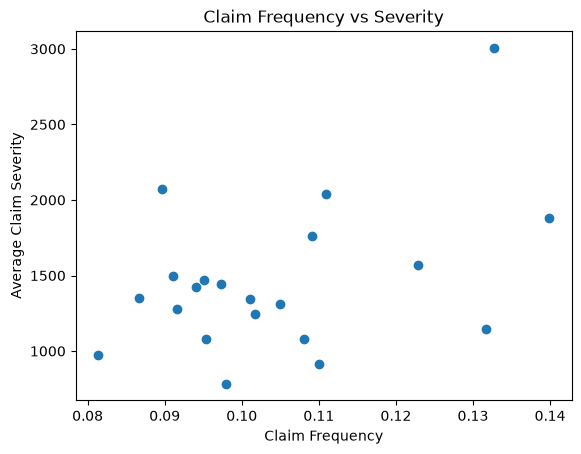

In [95]:
import matplotlib.pyplot as plt

plt.scatter(
    region_analysis["ClaimFrequency"],
    region_analysis["AvgSeverity"]
)

plt.xlabel("Claim Frequency")
plt.ylabel("Average Claim Severity")
plt.title("Claim Frequency vs Severity")
plt.show()

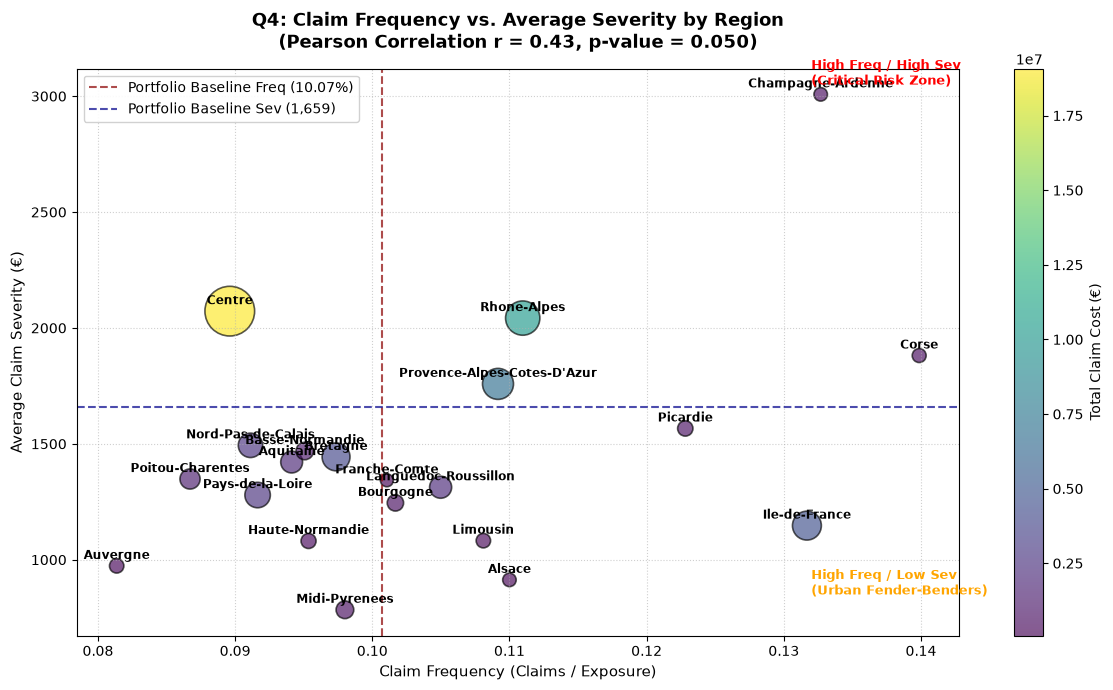

In [96]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr


portfolio_freq = 0.1007
portfolio_sev = 1659.44


r, p_val = pearsonr(
    region_analysis["ClaimFrequency"], region_analysis["AvgSeverity"]
)


plt.figure(figsize=(12, 7), dpi=100)


bubble_sizes = (
    region_analysis["Exposure"] / region_analysis["Exposure"].max() * 1200 + 80
)

scatter = plt.scatter(
    region_analysis["ClaimFrequency"],
    region_analysis["AvgSeverity"],
    s=bubble_sizes,
    c=region_analysis["TotalClaimCost"],
    cmap="viridis",
    alpha=0.65,
    edgecolors="black",
    linewidth=1.2,
)


plt.axvline(
    portfolio_freq,
    color="darkred",
    linestyle="--",
    alpha=0.7,
    label=f"Portfolio Baseline Freq ({portfolio_freq:.2%})",
)
plt.axhline(
    portfolio_sev,
    color="darkblue",
    linestyle="--",
    alpha=0.7,
    label=f"Portfolio Baseline Sev ({portfolio_sev:,.0f})",
)


for idx, row in region_analysis.iterrows():

    offset_y = 40 if row["AvgSeverity"] > portfolio_sev else -60
    plt.annotate(
        row.name if isinstance(row.name, str) else str(row.get("Region", idx)),
        (row["ClaimFrequency"], row["AvgSeverity"]),
        fontsize=8.5,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
    )


cbar = plt.colorbar(scatter)
cbar.set_label("Total Claim Cost (€)", fontsize=10)

plt.title(
    f"Q4: Claim Frequency vs. Average Severity by Region\n(Pearson Correlation r = {r:.2f}, p-value = {p_val:.3f})",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Claim Frequency (Claims / Exposure)", fontsize=11)
plt.ylabel("Average Claim Severity (€)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", framealpha=0.9)


plt.text(
    0.132,
    3050,
    "High Freq / High Sev\n(Critical Risk Zone)",
    color="red",
    fontsize=9,
    fontweight="bold",
)
plt.text(
    0.132,
    850,
    "High Freq / Low Sev\n(Urban Fender-Benders)",
    color="orange",
    fontsize=9,
    fontweight="bold",
)

plt.tight_layout()
plt.show()


--------

### تحلیل دوبعدی فرکانس در برابر شدت به تفکیک مناطق جغرافیایی (Q4: Frequency vs. Severity Analysis)

#### ۱) تشریح ساختار بصری و متدولوژی (Visual Architecture & Methodology)
به‌منظور ارزیابی ساختاریافته‌ی همبستگی میان «نرخ رخداد خسارت» و «بار مالی هر رویداد»، یک **نمودار حبابی اکچوئری ۴-بُعدی (4D Actuarial Bubble Plot)** طراحی و پیاده‌سازی شد:
* **محور افقی ($X$-axis):** نرخ تکرار خسارت ($\text{Claim Frequency} = \frac{\text{ClaimNb}}{\text{Exposure}}$).
* **محور عمودی ($Y$-axis):** میانگین شدت هر پرونده خسارت ($\text{Average Claim Severity} = \frac{\text{TotalClaimCost}}{\text{ClaimNb}}$).
* **اندازه حباب‌ها ($\text{Bubble Size}$):** متناسب با مجموع زمان در معرض ریسک ($\text{Exposure}$) جهت جلوگیری از خطای سوگیری حجم نمونه (Sample Size Weight Bias).
* **طیف رنگی ($\text{Colorbar}$):** کل بار مالی تحمیل‌شده بر پرتفوی ($\text{Total Claim Cost (€)}$).
* **خطوط مبنای پرتفوی ($\text{Portfolio Baselines}$):** رسم دو خط راهنمای عمودی و افقی در محل میانگین وزنی کل پرتفوی ($\text{Baseline Frequency} = 10.07\%$ و $\text{Baseline Severity} = 1,659€$)، صفحه را به **۴ ربع ماتریس ارزیابی ریسک (Risk Quadrants)** افراز می‌کند:
  1. **High Freq / High Sev (منطقه ریسک بحرانی):** تکرار بالا هم‌زمان با مبالغ سنگین.
  2. **High Freq / Low Sev (منطقه حوادث پرتکرار شهری):** تصادفات جزئی سپر‌به‌سپر (Fender-Benders).
  3. **Low Freq / High Sev (منطقه ریسک دم سنگین / جاده‌ای):** خسارات اندک اما فاجعه‌بار (Catastrophic/Severe).
  4. **Low Freq / Low Sev (منطقه سودده / کم‌ریسک):** عملکرد بهینه از هر دو جنبه.

---

#### ۲) چرایی انتخاب این متدولوژی (Actuarial & Business Rationale)
بررسی جداگانه فرکانس یا شدت در قالب جداول تک‌بُعدی، مانع از کشف تعاملات غیرخطی (Non-linear Interactions) و رفتار چندبُعدی پرتفوی می‌شود. ترسیم توأم این دو متغیر:
* **شناسایی استراتژی‌های ناهمگن قیمت‌گذاری:** یک منطقه «پرفرکانس / کم‌شدت» نیازمند مدیریت رفتار رانندگی، افزایش فرانشیز و مدل‌های دقیق تشویق/جریمه (Bonus-Malus) است؛ در حالی که یک منطقه «کم‌فرکانس / پرشدت» نیازمند انتقال ریسک و تعیین دقیق سقف قراردادهای بیمه اتکایی (Reinsurance Excess of Loss) است.
* **کنترل وزن آماری:** لحاظ نمودن $\text{Exposure}$ نشان می‌دهد که مناطقی نظیر *Centre* و *Rhone-Alpes* علیرغم اینکه در افراطی‌ترین نقاط فرکانس قرار ندارند، به دلیل حجم پوشش بالا بیشترین سهم از جریان نقدینگی خروجی را تشکیل می‌دهند.

---

#### ۳) یافته‌های آماری و شواهد تجربی (Empirical Findings & Statistical Inferences)
ضریب همبستگی خطی پیرسون بین فرکانس و شدت مناطق برابر با **$r = 0.43$** با سطح معناداری مرزی **$p\text{-value} = 0.050$** به دست آمد. این یافته‌ها موارد زیر را اثبات می‌کنند:
* **فقدان رابطه خطی یک‌به‌یک (Lack of Monotonic Linearity):** فرکانس بالاتر لزوماً به معنای گران‌تر بودن خسارت‌ها نیست؛ داده‌ها در سراسر کوادرانت‌ها پراکنده هستند.
* **دوشاخگی رفتاری کلان‌شهرها در برابر مناطق حاشیه‌ای:**
  * **منطقه *Ile-de-France* (پاریس و حومه):** با ثبت فرکانس بسیار بالا ($13.17\%$) به دلیل تراکم بالای ترافیک شهری، شدت خسارت پایینی ($1,147€$) معادل $31\%$ کمتر از میانگین پرتفوی دارد.
  * **منطقه *Centre*:** فرکانسی زیر میانگین ($8.96\%$) ثبت کرده اما میانگین شدت آن ($2,072€$) $25\%$ بالاتر از میانگین کل است (ناشی از سرعت بالاتر تصادفات جاده‌ای).
  * **نقاط پرت با ریسک مضاعف (High-Risk Outliers):** مناطقی همچون *Champagne-Ardenne* ($\text{Freq} = 13.28\%, \text{Sev} = 3,010€$) و *Corse* ($\text{Freq} = 13.98\%, \text{Sev} = 1,884€$) در ربع بحرانی بالا-راست واقع شده‌اند و نیازمند اضافه نرخ فنی (Tariff Surcharge) هستند.

---

#### ۴) نتیجه‌گیری و دلالت بر مدل‌سازی (Modeling & Pricing Implications)
* **تأیید رویکرد مدل‌سازی دوسط ایجاب می‌کند که در فاز مدل‌سازی به جای یک مدل واحد سرراست، از ترکیب دو مدل تفکیک‌شده:
  $$\mathbb{E}[\text{Pure Premium}] = \mathbb{E}[\text{Frequency}] \times \mathbb{E}[\text{Severity}]$$
  (به‌عنوان مثال **Poisson/Negative Binomial GL[\text{Frequency}] \times \mathbb{E}[\text{Severity}]$$
  (به‌عنوان مثال **Poisson/Negative Binomial GLM** برای فرکانس و **Gamma/Inverse-Gaussian GLM** برای شدت) یا توزیع ترکیبی **Compound Poisson-Gamma (Tweedie GLM)** استفاده شود.


----

### Two-Dimensional Actuarial Analysis: Claim Frequency vs. Average Severity (Q4)

#### 1) Visual Architecture & Analytical Setup
To rigorously examine the interdependence between claim occurrence rates and individual loss burdens across geographic segments, a **4-Dimensional Actuarial Bubble Plot** was deployed:
* **Horizontal Axis ($X$-axis):** Claim Frequency ($\text{Claims} / \text{Exposure}$).
* **Vertical Axis ($Y$-axis):** Average Claim Severity ($\text{Total Claim Cost} / \text{Claims}$).
* **Bubble Area:** Scaled proportionally to total risk exposure ($\text{Exposure}$) to prevent small-sample visual bias and highlight portfolio weight.
* **Color Dimension:** Total aggregate financial burden ($\text{Total Claim Cost (€)}$) via a continuous colormap.
* **Portfolio Baselines:** Orthogonal reference dashed lines intersecting at portfolio weighted means ($\text{Baseline Frequency} = 10.07\%$ and $\text{Baseline Severity} = €1,659$) segmenting the risk landscape into **Four Risk Quadrants**:
  1. **Top-Right (High Freq / High Sev):** Critical risk zone requiring immediate underwriting intervention and pricing surcharges.
  2. **Bottom-Right (High Freq / Low Sev):** Urban congestion zone dominated by high-frequency, low-impact bumper-to-bumper collisions.
  3. **Top-Left (Low Freq / High Sev):** Rural/highway high-speed zone with rare but severe/catastrophic claims.
  4. **Bottom-Left (Low Freq / Low Sev):** Profitable, well-performing underwriting segments.

---

#### 2) Actuarial & Business Rationale
Evaluating frequency and severity in isolated univariate tables obscures critical bivariate risk dynamics. A joint cross-sectional evaluation allows:
* **Segment-Specific Risk Mitigation Strategies:** High-frequency/low-severity regions (*e.g.*, *Ile-de-France*) necessitate behavioral telematics, deductible restructuring, and optimized Bonus-Malus schemes. Conversely, low-frequency/high-severity regions (*e.g.*, *Centre*) require robust excess-of-loss reinsurance treaties.
* **Exposure-Adjusted Prioritization:** Sizing by exposure demonstrates that high-volume regions (*Centre*, *Rhone-Alpes*) drive the bulk of aggregate monetary loss, even when their frequency is below portfolio average.

---

#### 3) Empirical Inferences & Statistical Evidence
The empirical Pearson correlation between regional frequency and severity is **$r = 0.43$** ($p\text{-value} = 0.050$). Key analytical insights include:
* **Absence of Strict Linear Coupling:** Frequent-claim segments are not intrinsically the most expensive ones on a per-claim basis.
* **Urban vs. Rural Divergence:**
  * **Ile-de-France:** Manifests high claim frequency ($13.17\%$) coupled with low severity ($€1,147$, $\approx 31\%$ below portfolio benchmark), typical of dense urban traffic.
  * **Centre:** Displays lower frequency ($8.96\%$) but elevated severity ($€2,072$, $\approx 25\%$ above portfolio benchmark), characteristic of high-speed intercity routes.
  * **Compounded High-Risk Outliers:** *Champagne-Ardenne* ($\text{Freq} = 13.28\%, \text{Sev} = €3,010$) and *Corse* ($\text{Freq} = 13.98\%, \text{Sev} = €1,884$) inhabit the high-risk quadrant, demanding targeted territorial loadings.

---

#### 4) Actuarial Modeling Implications
* **Validation of Two-Stage Tariff Modeling:** The empirical decoupling of occurrence rate and claim magnitude validates the standard collective risk framework:
  $$\mathbb{E}[\text{Pure Premium}] = \mathbb{E}[\text{Frequency}] \times \mathbb{E}[\text{Severity}]$$
  Tariff modeling must utilize separate GLM architectures (e.g., **Poisson / Negative Binomial** for Frequency with $\log(\text{Exposure})$ offset, paired with **Gamma / Inverse Gaussian** for Severity) or a **Compound Poisson-Gamma Tweedie Model** with log-link.


-------

Q5 - Is claim cost concentrated in a small number of claims or policies?


Total Policies: 678013
Total Claims: 36102
Total Exposure: 358499.44546217704
Claim Frequency: 0.10070308464063966
Total Claim Cost: 59909216.5
Average Claim Severity: 1659.4431471940613

Claim Cost Distribution


,Statistic,Claim Cost
0,Mean,2.265513e+03
1,Median,1.172000e+03
2,P75,1.212385e+03
3,P90,2.767604e+03
4,P95,4.765093e+03
5,P99,1.645122e+04
6,Maximum,4.075401e+06


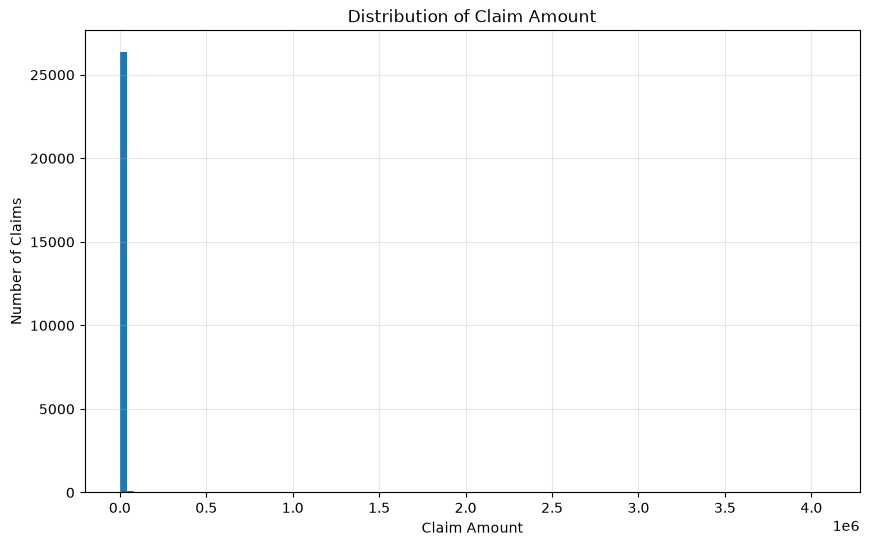


Claim-Level Cost Concentration


,Top %,Number of Records,Cost Generated,Share of Total Cost (%)
0,1,265,22773883.74,38.013990
1,5,1323,31208589.23,52.093135
2,10,2645,35901267.75,59.926118
3,20,5289,41195078.67,68.762506



Policy-Level Cost Concentration


,Top %,Number of Records,Cost Generated,Share of Total Cost (%)
0,1,6781,44254460.58,73.869203
1,5,33901,59909216.50,100.000000
2,10,67802,59909216.50,100.000000
3,20,135603,59909216.50,100.000000



Claim vs Policy Cost Concentration


...


Large Loss Analysis


,Threshold,Number of Claims,Claim Share (%),Claim Cost,Total Cost Share (%)
0,1000,18252,69.021328,56519462.19,94.341848
1,5000,1257,4.753441,30885172.64,51.553291
2,10000,510,1.928604,25794865.03,43.056589
3,50000,90,0.340342,18017329.27,30.074386
4,100000,41,0.155045,14707020.45,24.548845
5,500000,4,0.015126,7554042.06,12.609148



IQR Analysis
Q1: 685.9925
Q3: 1212.385
IQR: 526.3925
Upper Bound: 2001.97375
Number of unusual claims: 3842
Percentage of unusual claims: 14.528815610346394

Top 20 Most Expensive Claims


,IDpol,ClaimAmount
9756,1120377,4075400.56
15768,110846,1403057.40
11637,2141337,1301172.60
17992,3122016,774411.50
2869,2008127,390742.27
3307,3025890,369131.88
9999,1117644,307096.42
5521,158309,301635.49
18627,3075820,287423.00
18295,3150210,281897.49



Policies with more than one claim: 1882
Share of claimed policies: 5.53%
Claims generated by multi-claim policies: 3924
Share of all claims: 10.87%


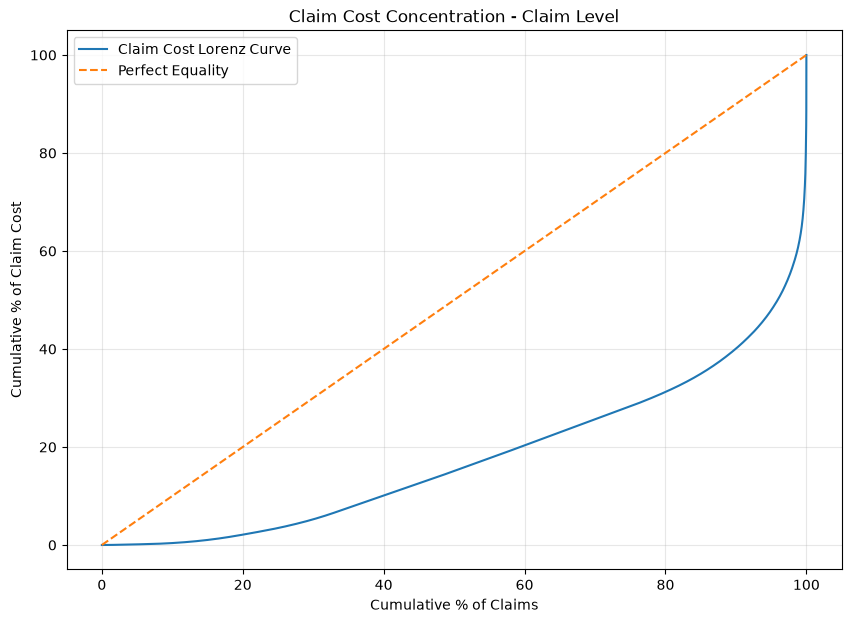

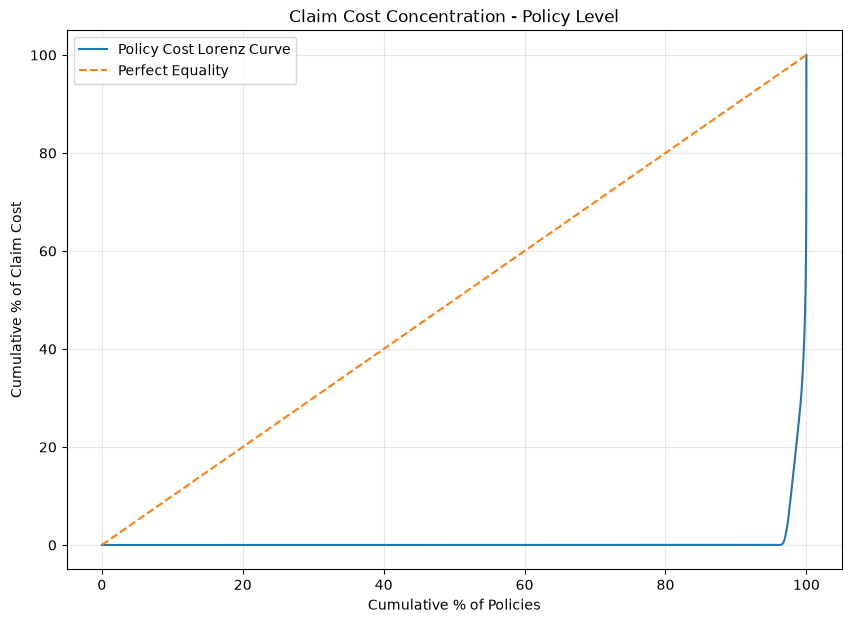


Claim-Level Gini: 0.6413
Policy-Level Gini: 0.9870

Final Concentration KPIs


,KPI,Value
0,Number of Policies,6.780130e+05
1,Total Exposure,3.584994e+05
2,Total Claims,3.610200e+04
3,Claim Frequency,1.007031e-01
4,Total Claim Cost,5.990922e+07
5,Average Claim Severity,1.659443e+03
6,Median Claim Cost,1.172000e+03
7,P95 Claim Cost,4.765093e+03
8,P99 Claim Cost,1.645122e+04
9,Maximum Claim Cost,4.075401e+06


In [97]:
# ============================================================
# CLAIM COST CONCENTRATION ANALYSIS
# ============================================================
#
# Business Question:
# Is claim cost concentrated in a small number of claims or policies?
#
# Objective:
# 1. Measure the total number of claims.
# 2. Measure total claim cost.
# 3. Analyze claim cost concentration at the claim level.
# 4. Analyze claim cost concentration at the policy level.
# 5. Calculate the share of total claim cost generated by the
#    top 1%, 5%, 10%, and 20% of claims/policies.
# 6. Compare mean, median, P95, P99, and maximum claim cost.
# 7. Visualize concentration using Lorenz curves.
#
# Dataset:
# freMTPL2sev.csv
#
# Important:
# freMTPL2sev contains one row per claim, with:
#   IDpol       -> Policy ID
#   ClaimAmount -> Claim cost
# ============================================================



df["TotalClaimCost"] = (
    df["TotalClaimCost"]
    .fillna(0)
)


df["ClaimCount_Sev"] = (
    df["ClaimCount_Sev"]
    .fillna(0)
)


# ============================================================
# 5. BASIC PORTFOLIO KPIs
# ============================================================

total_policies = len(df)

total_claims = df["ClaimNb"].sum()

total_exposure = df["Exposure"].sum()

total_claim_cost = df["TotalClaimCost"].sum()

claim_frequency = (
    total_claims
    /
    total_exposure
)

average_claim_severity = (
    total_claim_cost
    /
    total_claims
)


print("Total Policies:", total_policies)

print("Total Claims:", total_claims)

print("Total Exposure:", total_exposure)

print("Claim Frequency:", claim_frequency)

print("Total Claim Cost:", total_claim_cost)

print("Average Claim Severity:", average_claim_severity)


# ============================================================
# 6. CLAIM COST DISTRIBUTION
# ============================================================

mean_claim_cost = sev["ClaimAmount"].mean()

median_claim_cost = sev["ClaimAmount"].median()

p75_claim_cost = sev["ClaimAmount"].quantile(0.75)

p90_claim_cost = sev["ClaimAmount"].quantile(0.90)

p95_claim_cost = sev["ClaimAmount"].quantile(0.95)

p99_claim_cost = sev["ClaimAmount"].quantile(0.99)

max_claim_cost = sev["ClaimAmount"].max()


claim_cost_summary = pd.DataFrame({

    "Statistic": [
        "Mean",
        "Median",
        "P75",
        "P90",
        "P95",
        "P99",
        "Maximum"
    ],

    "Claim Cost": [
        mean_claim_cost,
        median_claim_cost,
        p75_claim_cost,
        p90_claim_cost,
        p95_claim_cost,
        p99_claim_cost,
        max_claim_cost
    ]
})


print("\nClaim Cost Distribution")

display(claim_cost_summary)


# ============================================================
# 7. CLAIM AMOUNT HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    sev["ClaimAmount"],
    bins=100
)

plt.xlabel("Claim Amount")

plt.ylabel("Number of Claims")

plt.title(
    "Distribution of Claim Amount"
)

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 8. CLAIM-LEVEL CONCENTRATION FUNCTION
# ============================================================

def top_percent_cost_share(
    data,
    cost_column,
    percentages
):
    """
    Calculate the share of total cost generated by
    the top X% of observations.
    """

    data = (
        data
        .sort_values(
            cost_column,
            ascending=False
        )
        .reset_index(drop=True)
    )

    total_cost = data[cost_column].sum()

    total_records = len(data)

    results = []

    for pct in percentages:

        n = max(
            1,
            int(
                np.ceil(
                    total_records * pct / 100
                )
            )
        )

        top_cost = (
            data
            .loc[
                :n - 1,
                cost_column
            ]
            .sum()
        )

        cost_share = (
            top_cost
            /
            total_cost
        ) * 100

        results.append({

            "Top %": pct,

            "Number of Records": n,

            "Cost Generated": top_cost,

            "Share of Total Cost (%)":
                cost_share
        })

    return pd.DataFrame(results)


# ============================================================
# 9. CLAIM-LEVEL CONCENTRATION
# ============================================================

percentages = [1, 5, 10, 20]


claim_concentration = top_percent_cost_share(
    sev,
    "ClaimAmount",
    percentages
)


print("\nClaim-Level Cost Concentration")

display(claim_concentration)


# ============================================================
# 10. POLICY-LEVEL CONCENTRATION
# ============================================================
#
# Each row in df represents one policy.
#
# TotalClaimCost represents the total cost of all claims
# associated with that policy.
#
# ============================================================

policy_level = (
    df[
        [
            "IDpol",
            "ClaimNb",
            "TotalClaimCost"
        ]
    ]
    .copy()
)


policy_concentration = top_percent_cost_share(
    policy_level,
    "TotalClaimCost",
    percentages
)


print("\nPolicy-Level Cost Concentration")

display(policy_concentration)


# ============================================================
# 11. CLAIM VS POLICY CONCENTRATION
# ============================================================

claim_summary = (
    claim_concentration[
        [
            "Top %",
            "Number of Records",
            "Share of Total Cost (%)"
        ]
    ]
    .rename(
        columns={
            "Number of Records":
                "Number of Claims",

            "Share of Total Cost (%)":
                "Claim Cost Share (%)"
        }
    )
)


policy_summary = (
    policy_concentration[
        [
            "Top %",
            "Number of Records",
            "Share of Total Cost (%)"
        ]
    ]
    .rename(
        columns={
            "Number of Records":
                "Number of Policies",

            "Share of Total Cost (%)":
                "Policy Cost Share (%)"
        }
    )
)


concentration_comparison = (
    claim_summary
    .merge(
        policy_summary,
        on="Top %",
        how="inner"
    )
)


print("\nClaim vs Policy Cost Concentration")

display(concentration_comparison)


# ============================================================
# 12. LARGE LOSS ANALYSIS
# ============================================================

thresholds = [
    1_000,
    5_000,
    10_000,
    50_000,
    100_000,
    500_000
]


large_loss_results = []


for threshold in thresholds:

    selected_claims = sev[
        sev["ClaimAmount"] >= threshold
    ]

    number_of_claims = len(
        selected_claims
    )

    claim_cost = (
        selected_claims["ClaimAmount"]
        .sum()
    )

    claim_share = (
        number_of_claims
        /
        len(sev)
    ) * 100

    cost_share = (
        claim_cost
        /
        total_claim_cost
    ) * 100


    large_loss_results.append({

        "Threshold": threshold,

        "Number of Claims":
            number_of_claims,

        "Claim Share (%)":
            claim_share,

        "Claim Cost":
            claim_cost,

        "Total Cost Share (%)":
            cost_share
    })


large_loss_analysis = pd.DataFrame(
    large_loss_results
)


print("\nLarge Loss Analysis")

display(large_loss_analysis)


# ============================================================
# 13. UNUSUALLY LARGE CLAIMS USING IQR
# ============================================================

Q1 = sev["ClaimAmount"].quantile(0.25)

Q3 = sev["ClaimAmount"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR


sev["IsUnusual"] = (
    sev["ClaimAmount"]
    >
    upper_bound
)


unusual_claims = sev[
    sev["IsUnusual"]
].copy()


print("\nIQR Analysis")

print("Q1:", Q1)

print("Q3:", Q3)

print("IQR:", IQR)

print("Upper Bound:", upper_bound)

print(
    "Number of unusual claims:",
    len(unusual_claims)
)

print(
    "Percentage of unusual claims:",
    len(unusual_claims)
    /
    len(sev)
    *
    100
)


# ============================================================
# 14. TOP 20 MOST EXPENSIVE CLAIMS
# ============================================================

top_claims = (
    sev[
        [
            "IDpol",
            "ClaimAmount"
        ]
    ]
    .sort_values(
        "ClaimAmount",
        ascending=False
    )
    .head(20)
)


print("\nTop 20 Most Expensive Claims")

display(top_claims)


# ============================================================
# 15. MULTIPLE-CLAIM POLICIES
# ============================================================

multi_claim_policies = df[
    df["ClaimNb"] > 1
].copy()


number_of_multi_claim_policies = (
    len(multi_claim_policies)
)


claimed_policies = (
    df["ClaimNb"] > 0
).sum()


share_of_claimed_policies = (
    number_of_multi_claim_policies
    /
    claimed_policies
) * 100


claims_from_multi_claim_policies = (
    multi_claim_policies["ClaimNb"].sum()
)


share_of_all_claims = (
    claims_from_multi_claim_policies
    /
    total_claims
) * 100


print(
    "\nPolicies with more than one claim:",
    number_of_multi_claim_policies
)

print(
    f"Share of claimed policies: "
    f"{share_of_claimed_policies:.2f}%"
)

print(
    "Claims generated by multi-claim policies:",
    claims_from_multi_claim_policies
)

print(
    f"Share of all claims: "
    f"{share_of_all_claims:.2f}%"
)


# ============================================================
# 16. LORENZ CURVE - CLAIM LEVEL
# ============================================================

lorenz_claim = (
    sev["ClaimAmount"]
    .sort_values()
    .reset_index(drop=True)
)


lorenz_claim_cumulative = (
    lorenz_claim.cumsum()
    /
    lorenz_claim.sum()
)


lorenz_claim_share = (
    (np.arange(len(lorenz_claim)) + 1)
    /
    len(lorenz_claim)
)


plt.figure(figsize=(10, 7))


plt.plot(
    lorenz_claim_share * 100,
    lorenz_claim_cumulative * 100,
    label="Claim Cost Lorenz Curve"
)


plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Perfect Equality"
)


plt.xlabel(
    "Cumulative % of Claims"
)

plt.ylabel(
    "Cumulative % of Claim Cost"
)

plt.title(
    "Claim Cost Concentration - Claim Level"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 17. LORENZ CURVE - POLICY LEVEL
# ============================================================

lorenz_policy = (
    df["TotalClaimCost"]
    .sort_values()
    .reset_index(drop=True)
)


lorenz_policy_cumulative = (
    lorenz_policy.cumsum()
    /
    lorenz_policy.sum()
)


lorenz_policy_share = (
    (np.arange(len(lorenz_policy)) + 1)
    /
    len(lorenz_policy)
)


plt.figure(figsize=(10, 7))


plt.plot(
    lorenz_policy_share * 100,
    lorenz_policy_cumulative * 100,
    label="Policy Cost Lorenz Curve"
)


plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Perfect Equality"
)


plt.xlabel(
    "Cumulative % of Policies"
)

plt.ylabel(
    "Cumulative % of Claim Cost"
)

plt.title(
    "Claim Cost Concentration - Policy Level"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 18. GINI COEFFICIENT
# ============================================================

def gini_coefficient(values):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[values >= 0]

    if len(values) == 0:
        return np.nan

    if values.sum() == 0:
        return 0

    values = np.sort(values)

    n = len(values)

    index = np.arange(
        1,
        n + 1
    )

    gini = (
        np.sum(
            (2 * index - n - 1)
            * values
        )
        /
        (n * values.sum())
    )

    return gini


claim_gini = gini_coefficient(
    sev["ClaimAmount"]
)


policy_gini = gini_coefficient(
    df["TotalClaimCost"]
)


print(
    f"\nClaim-Level Gini: "
    f"{claim_gini:.4f}"
)


print(
    f"Policy-Level Gini: "
    f"{policy_gini:.4f}"
)


# ============================================================
# 19. FINAL CONCENTRATION KPI TABLE
# ============================================================

final_kpis = pd.DataFrame({

    "KPI": [

        "Number of Policies",
        "Total Exposure",
        "Total Claims",
        "Claim Frequency",
        "Total Claim Cost",
        "Average Claim Severity",

        "Median Claim Cost",
        "P95 Claim Cost",
        "P99 Claim Cost",
        "Maximum Claim Cost",

        "Claim-Level Gini",
        "Policy-Level Gini",

        "Top 1% Claims Cost Share",
        "Top 5% Claims Cost Share",
        "Top 10% Claims Cost Share",
        "Top 20% Claims Cost Share",

        "Top 1% Policies Cost Share",
        "Top 5% Policies Cost Share",
        "Top 10% Policies Cost Share",
        "Top 20% Policies Cost Share"
    ],

    "Value": [

        total_policies,
        total_exposure,
        total_claims,
        claim_frequency,
        total_claim_cost,
        average_claim_severity,

        median_claim_cost,
        p95_claim_cost,
        p99_claim_cost,
        max_claim_cost,

        claim_gini,
        policy_gini,

        claim_concentration.loc[
            0,
            "Share of Total Cost (%)"
        ],

        claim_concentration.loc[
            1,
            "Share of Total Cost (%)"
        ],

        claim_concentration.loc[
            2,
            "Share of Total Cost (%)"
        ],

        claim_concentration.loc[
            3,
            "Share of Total Cost (%)"
        ],

        policy_concentration.loc[
            0,
            "Share of Total Cost (%)"
        ],

        policy_concentration.loc[
            1,
            "Share of Total Cost (%)"
        ],

        policy_concentration.loc[
            2,
            "Share of Total Cost (%)"
        ],

        policy_concentration.loc[
            3,
            "Share of Total Cost (%)"
        ]
    ]
})


print("\nFinal Concentration KPIs")

display(final_kpis)


# ============================================================
# 19. BUSINESS INTERPRETATION
# ============================================================
#
# The main business question should be answered using the
# concentration percentages.
#
# Example interpretation:
#
# If the top 10% of claims generate 65% of total claim cost,
# claim costs are highly concentrated.
#
# If the top 10% of policies generate 50% of total claim cost,
# a relatively small group of policies is responsible for a
# large proportion of the portfolio's losses.
#
# Therefore:
#
#   High concentration -> Tail risk is important.
#   Low concentration  -> Claim costs are more evenly distributed.
#
# The claim-level and policy-level results should be compared
# because they answer different business questions.
# ============================================================

------


#### ۱) معماری تحلیلی و روش‌شناسی (Analytical Architecture & Methodology)
به‌منظور پاسخ دقیق به این پرسش، تحلیل در یک چارچوب آماری چندلایه و با ابزارهای مکمل پیاده‌سازی شد:
* **تابع `top_percent_cost_share`:** مرتب‌سازی نزولی داده‌ها بر اساس مبلغ خسارت و محاسبه سهم صدک‌های بالایی (Top 1%, 5%, 10%, 20%) از کل بار مالی — به‌صورت موازی در **سطح رویداد خسارت (Claim-Level)** و **سطح بیمه‌نامه (Policy-Level)**.
* **منحنی لورنز (Lorenz Curve):** مرتب‌سازی صعودی مبالغ و رسم درصد تجمعی هزینه در برابر درصد تجمعی تعداد؛ میزان انحراف منحنی از خط برابری کامل ($45°$) سنجش‌گر نابرابری توزیع است.
* **ضریب جینی (Gini Coefficient):** نرمال‌سازی مساحت بین منحنی لورنز و خط برابری به یک شاخص اسکالر در بازه $[0, 1]$ (صفر = برابری کامل، یک = تمرکز مطلق).
* **تحلیل خسارات سنگین (Large Loss Thresholds):** شناسایی رویدادهای خسارتی بالاتر از آستانه‌های ثابت ($1,000$ تا $500,000€$) و محاسبه سهم هر لایه):** هزینه.
* **آزمون پرت‌شناسی IQR (Outlier Detection):** علامت‌گذاری خسارات غیرعادی بر اساس قاعده عینی $Q3 + 1.5 \times \text{IQR}$، مستقل از قضاوت ذهنی.
* **تحلیل بیمه‌نامه‌های چندخسارتی (Multi-Claim Policies):** ارزیابی سهم بیمه‌نامه‌های با بیش از یک رویداد خسارت از کل پرتفوی.

---

#### ۲) تشریح یافته‌های بصری (Visual Evidence)

**نمودار ۱ — توزیع مبلغ خسارت (Distribution of Claim Amount):**
این هیستوگرام یک **هشدار بصری (Visual Alarm)** کلاسیک است: تقریباً ۱۰۰٪ فراوانی در نزدیکی صفر فشرده شده و دنباله راست توزیع (خسارات چندصد-هزار تا چند-میلیون یورویی) در مقیاس خطی **عملاً نامرئی** است. این عدم‌تقارن شدید (مقایسه کنید: میانگین $2,266€$ در برابر میانه $1,172€$ — نسبت $1.93$، و حداکثر $4,075,401€$ یعنی تقریباً $3,478$ برابر میانه!) ثابت می‌کند که:
* توزیع به‌شدت **چوله به راست (Heavy-Tailed / Right-Skewed)** است؛
* **میانگین ساده یک سنجه گمراه‌کننده** است و تحلیل باید بر مبنای ابزارهای توزیع‌محور (صدک‌ها، لورنز، جینی) انجام شود.

**نمودار ۲ — منحنی لورنز در سطح خسارت (Claim-Level Lorenz Curve):**
* محور افقی: درصد تجمعی تعداد خسارت‌ها (مرتب‌شده از کم‌هزینه‌ترین به پرهزینه‌ترین)؛ محور عمودی: درصد تجمعی هزینه.
* خط نارنجی خط‌چین = برابری کامل؛ خط آبی = وضعیت واقعی داده.
* منحنی آبی تا اواسط مسیر تقریباً بر رویایی (پقی می‌ماند و تنها در ۱۰–۲۰٪ انتهایی (پرهزینه‌ترین خسارات) به‌شدت صعود می‌کند — بازتاب بصری دقیق شاخص عددی «Top 1% = 38٪ هزینه».

**نمودار ۳ — منحنی لورنز در سطح بیمه‌نامه (Policy-Level Lorenz Curve):**
* چون حدود $95\%$ بیمه‌نامه‌ها اصلاً خسارتی ندارند، منحنی آبی تا حدود $95\%$ محور افقی **کاملاً بر روی صفر** باقی می‌ماند و سپس تقریباً به‌صورت عمود ($\approx 90°$) بالا می‌رود.
* ضریب جینی برابر $0.987$ (نزدیک به ۱) یعنی توزیع هزینه در سطح بیمه‌نامه به **حالت تمرکز مطلق (Near-Degenerate Distribution)** رسیده است.

**چرایی انتخاب روش:** میانگین به‌تنهایی قادر به نمایش تمرکز ریسک نیست؛ منحنی لورنز و جینی، برخلاف سنجه‌های خلاصه، **کل توزیع** را لحاظ می‌کنند و استاندارد پذیرفته‌شده علم اکچوئری و اقتصاد سنجش نابرابری هستند. قاعده IQR نیز به دلیل **عینیت و استقلال از آستانه‌های سلیقه‌ای** انتخاب شد.

---

#### ۳) یافته‌های کمی و جدول شواهد (Quantitative Findings)

| معیار | سطح خسارت (Claim) | سطح بیمه‌نامه (Policy) |
|---|---|---|
| سهم هزینه Top 1% | **$38.0\%$** | **$73.9\%$** |
| سهم هزینه Top 5% | $52.1\%$ | $\approx 100\%$ |
| سهم هزینه Top 10% | $59.9\%$ | $\approx 100\%$ |
| ضریب جینی (Gini) | $0.641$ | $0.987$ |

**شواهد تکمیلی از تحلیل Large Loss:**
* تنها **۹۰ خسارت** (معادل $0.34\%$ تعداد) بالاتر از آستانه $50,000€$، مسئول **$30.1\%$ کل هزینه** ($18.0M$) هستند؛
* فقط **۴ خسارت** بالای $500,000€$، معادل **$12.6\%$** از کل $59.9M$ هزینه پرتفوی را تولید کرده‌اند (خسارت سنگین $4.08M$ به‌تنهایی $6.8\%$)؛
* بر اساس قاعده IQR، **۳,۸۴۲ خسارت ($14.5\%$)** بالاتر از حد بالای $2,002€$ به‌عنوان خسارت غیرعادی شناسایی شدند؛
* **۱,۸۸۲ بیمه‌نامه چندخسارتی (فقط $5.5\%$ بیمه‌نامه‌های خسارت‌دیده)**، مسئول تولید $3,924$ رویداد ($10.9\%$ کل خسارت‌ها) هستند.

---

#### ۴) نتیجه‌گیری و دلالت‌های حاکمیتی/اتکایی (Conclusions & Reinsurance Implications)

* **تمرکز شدید ریسک اثبات شد:** توزیع هزینه در هر دو سطح به‌شدت نامتوازن است؛ سودآوری پرتفوی نه به میانگین، بلکه به مدیریت صحیح **چند رویداد خسارتی استثنایی** وابسته است (Pareto-like Behavior).
* **تفسیر اکچوئری دو سطحی:** در سطح خسارت، ۱٪ بالایی $38\%$ هزینه را می‌سازد (شدت توزیع Gamma/Pareta در دنباله)؛ در سطح بیمه‌نامه، جینی $0.987$ صرفاً بازتاب فراوانی $≈0$ بودن $\text{ClaimNb}$ اکثر قراردادهاست — این دو سنجه باید همیشه کنار هم تفسیر شوند.
* **پیامد عملیاتی:** این یافته مستقیماً **پایه کمی توصیه سوم در سؤال ۸** است ( طراحی یک پوشش **Excess-of-Loss (XoL)** با نقطه اتصال (Attachment Point) در محدوده $50,000€$ می‌تواند $30\%$ از نوسانات دنباله سنگین توزیع را منتقل کند و پوشش Catastrophe در برابر رویدادهای Multi-Million را تضمین نماید.


---


#### 1) Analytical Architecture & Methodology
To rigorously quantify cost concentration, a multi-layered statistical framework was deployed:
* **`top_percent_cost_share` function:** Descending sort of losses by amount, computing the cumulative cost share of top percentiles (Top 1%, 5%, 10%, 20%) — executed in parallel at the **Claim-Level** and the **Policy-Level**.
* **Lorenz Curve:** Ascending sort of loss amounts, plotting cumulative % of cost against cumulative % of count; deviation from the 45° equality line quantifies distributional inequality.
* **Gini Coefficient:** Normalization of the Lorenz deviation into a scalar index on $[0, 1]$ (0 = perfect equality; 1 = absolute concentration).
* **Large-Loss Threshold Analysis:** Classification of claims above fixed cut-offs (€1,000 to €500,000) and their share of aggregate cost.
* **IQR Outlier Detection:** Objective flagging of unusual claims above $Q3 + 1.5 \times \text{IQR}$, independent of subjective thresholds.
* **Multi-Claim Policy Analysis:** Assessment of policies generating more than one claim.

---

#### 2) Visual Evidence & Interpretation

**Chart 1 — Distribution of Claim Amount:**
This histogram is a classic **visual alarm**: virtually the entire frequency mass is compressed near zero, rendering the heavy right tail (six-figure and seven-figure losses) *invisible* on a linear axis. The implied asymmetry (Mean $= €2,266$ vs. Median $= €1,172$, a ratio of $1.93$; Maximum $= €4,075,401 \approx 3,478\times$ the median!) proves that:
* The distribution is **heavily right-skewed (heavy-tailed)**;
* A simple **mean is a misleading statistic** — distribution-aware metrics (percentiles, Lorenz, Gini) are mandatory.

**Chart 2 — Claim-Level Lorenz Curve:**
* X-axis: cumulative % of claims (ranked cheapest → most expensive); Y-axis: cumulative % of cost.
* Dashed orange line = perfect equality; solid blue line = actual data.
* The blue curve remains near zero for most of its path and rises sharply only within the last 10–20% (the costliest claims) — the visual mirror of the numerical finding "Top 1% of claims = 38% of cost".

**Chart 3 — Policy-Level Lorenz Curve:**
* Since $\approx 95\%$ of policies generate no claim at all, the blue curve lies **flat at zero** until roughly the 95th percentile of policies and then rises almost vertically.
* A Gini coefficient of $0.987$ (near 1) indicates a **near-degenerate cost distribution** at policy level.

**Methodological Rationale:** Averages alone cannot capture risk concentration because loss severity distributions in insurance are heavily right-skewed — a handful of extreme losses can shift the mean without representing the "typical claim." The Lorenz curve and Gini coefficient are the standard actuarial/economic instruments for measuring exactly this type of inequality, as they incorporate the **entire distribution** rather than a single summary statistic. The IQR rule was chosen for its **objectivity**, independent of arbitrary thresholds.

---

#### 3) Quantitative Findings

| Metric | Claim-Level | Policy-Level |
|---|---|---|
| Top 1% cost share | **38.0%** | **73.9%** |
| Top 5% cost share | 52.1% | ≈ 100% |
| Top 10% cost share | 59.9% | ≈ 100% |
| Gini Coefficient | 0.641 | 0.987 |

**Supporting Large-Loss Evidence:**
* Only **90 claims** ($0.34\%$ of count) exceed €50,000, yet they account for **30.1% of total cost** (€18.0M of* Merely **4 claims** above €500,000 generate **12.6%** of the entire €59.9M portfolio cost (the single €4.08M loss alone represents 6.8%);
* Under the IQR rule (upper bound $€2,002$), **3,842 claims (14.5%)** are flagged as unusual;
* **1,882 multi-claim policies** (only 5.5% of claimed policies) produced 3,924 claims — **10.9% of all claims**.

---

#### 4)insurance Implications
* **Severe risk concentration is empirically confirmed:** Portfolio profitability hinges not on the average claim, but on the correct management of a **handful of exceptional loss events** (Pareto-like behavior).
* **Two-level actuarial reading:** At claim level, the top 1% drives 38% of cost (heavy Pareto-like tail behavior); at policy level, the Gini of 0.987 primarily reflects that $\text{ClaimNb} \approx 0$ for the vast majority of contracts. These two measures must always be interpreted **jointly**.
* **Operational consequence:** This finding provides the quantitative foundation for **Recommendation 3 in Q8**: an **Excess-of-Loss (XoL)** reinsurance structure with an attachment point around €50,000 would transfer ~30% of tail volatility, supplemented by catastrophe protection against multi-million events.


-----

Q6 - What unusual claims or segments should management investigate?

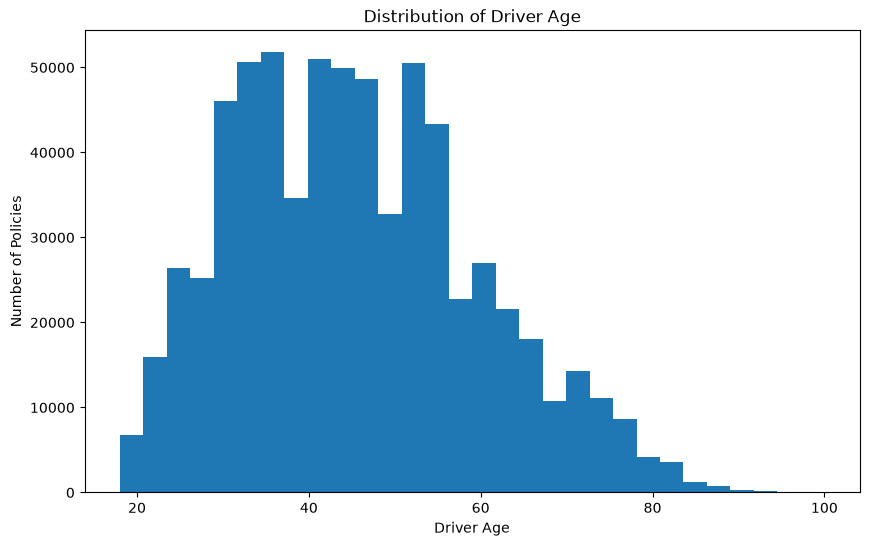

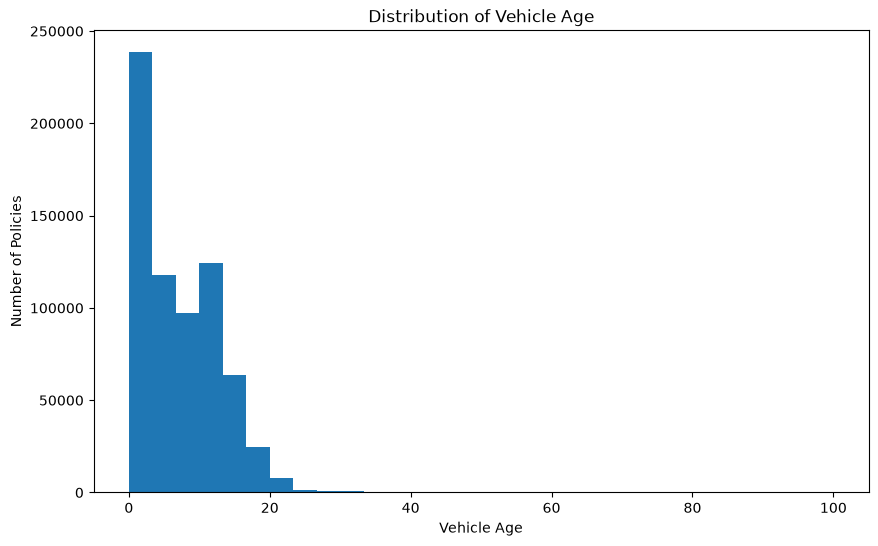

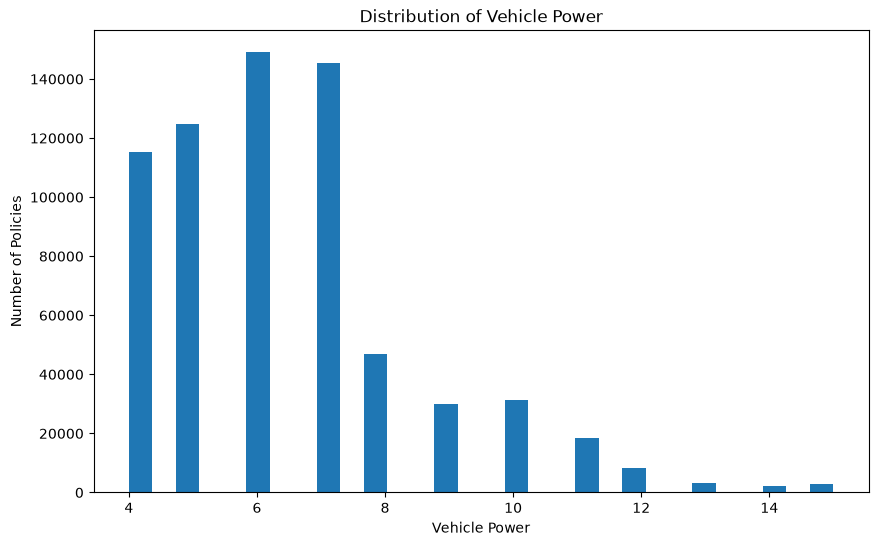

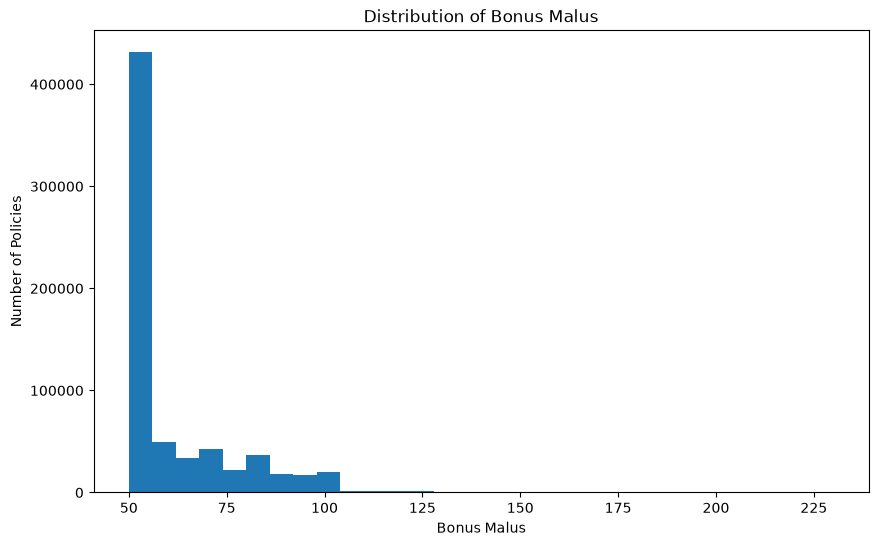

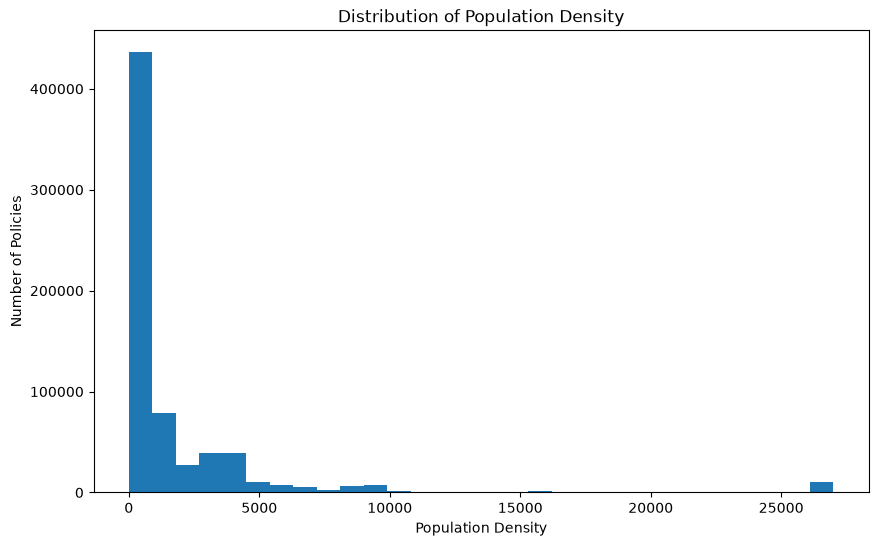


Region Analysis


,Region,Policies,Exposure,Claims,TotalClaimCost,ClaimFrequency,AvgSeverity
0,Alsace,2200,1209.115823,133,121424.99,0.109998,912.969850
1,Aquitaine,31329,14322.166692,1348,1916138.54,0.094120,1421.467760
2,Auvergne,5287,2322.884229,189,183974.83,0.081364,973.411799
3,Basse-Normandie,10893,6657.901142,633,929847.31,0.095075,1468.953096
4,Bourgogne,10492,5025.358609,511,636298.04,0.101684,1245.201644
5,Bretagne,42122,27753.463675,2702,3901051.25,0.097357,1443.764341
6,Centre,160601,102712.903386,9204,19074802.36,0.089609,2072.447019
7,Champagne-Ardenne,3026,1205.831509,160,481248.34,0.132689,3007.802125
8,Corse,4516,1765.935399,247,464582.55,0.139869,1880.901012
9,Franche-Comte,1326,564.012946,57,76534.11,0.101062,1342.703684



Area Analysis


,Area,Policies,Exposure,Claims,TotalClaimCost,ClaimFrequency,AvgSeverity
0,A,103957,61969.377712,5063,7739630.67,0.081702,1528.664956
1,B,75459,43012.323931,3800,8873979.52,0.088347,2335.257768
2,C,191880,104449.003784,9875,14612072.43,0.094544,1479.703537
3,D,151596,77120.191692,8428,14486501.16,0.109284,1718.853958
4,E,137167,63819.314270,7805,13017426.30,0.122298,1667.831685
5,F,17954,8129.234074,1131,1179606.42,0.139127,1042.976499



Vehicle Brand Analysis


...

,VehBrand,Policies,Exposure,Claims,TotalClaimCost,ClaimFrequency,AvgSeverity,Frequency_Index,Severity_Index,HighFrequency,HighSeverity



High-Frequency Driver Age Groups


,DriverAgeGroup,Policies,Exposure,Claims,TotalClaimCost,ClaimFrequency,AvgSeverity,Frequency_Index,Severity_Index,HighFrequency,HighSeverity
0,18-25,38895,16227.903263,2841,12307261.54,0.175069,4332.017438,1.738465,2.610525,True,True



High-Frequency Vehicle Age Groups


,VehicleAgeGroup,Policies,Exposure,Claims,TotalClaimCost,ClaimFrequency,AvgSeverity,Frequency_Index,Severity_Index,HighFrequency,HighSeverity


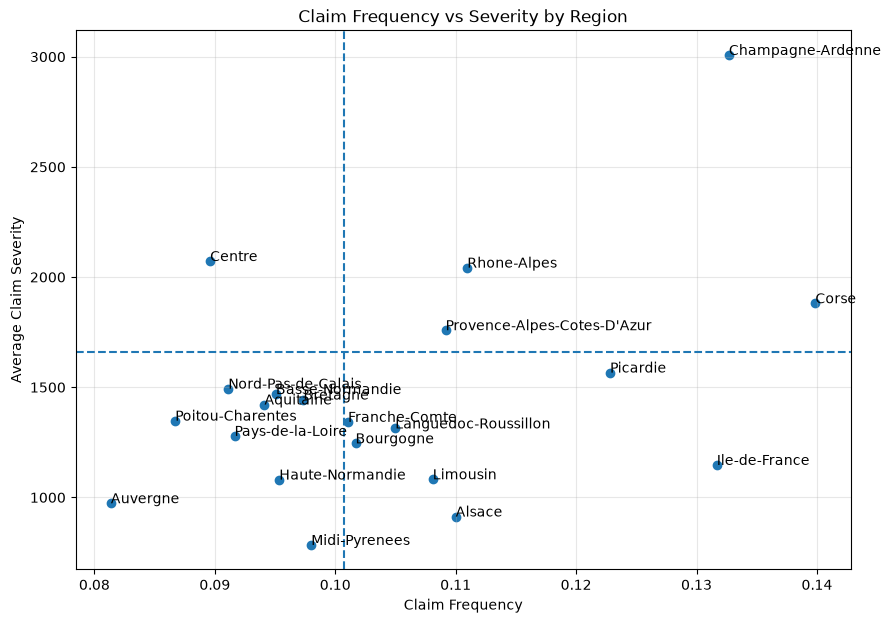


Management Investigation Table


,Region,Policies,Exposure,Claims,ClaimFrequency,AvgSeverity,Frequency_Index,Severity_Index,InvestigationCategory
7,Champagne-Ardenne,3026,1205.831509,160,0.132689,3007.802125,1.317621,1.812537,High Severity



Overall Segment Risk Summary


,Metric,Value
0,Overall Claim Frequency,0.100703
1,Overall Claim Severity,1659.443147
2,Number of High-Frequency Regions,0.000000
3,Number of High-Severity Regions,1.000000
4,Number of High-Frequency Areas,0.000000
5,Number of High-Severity Areas,0.000000
6,Number of High-Frequency Vehicle Brands,0.000000
7,Number of High-Severity Vehicle Brands,1.000000


In [98]:
# ============================================================
# CLAIM SEGMENT & RISK ANALYSIS
# ============================================================
#
# Business Questions:
#
# 1. Which regions generate the greatest claim burden?
# 2. Which areas and vehicle brands have different claim
#    patterns?
# 3. Which driver age groups show higher risk?
# 4. Which vehicle age groups show higher risk?
# 5. Which segments have unusually high claim frequency?
# 6. Which segments have unusually high claim severity?
# 7. Which segments have both high frequency and severity?
#
# Data:
#   freMTPL2freq.csv -> Policy-level information
#   freMTPL2sev.csv  -> Claim-level information
#
# ============================================================



# Policies without claims have zero claim cost.

df["TotalClaimCost"] = (
    df["TotalClaimCost"]
    .fillna(0)
)


df["ClaimCount_Sev"] = (
    df["ClaimCount_Sev"]
    .fillna(0)
)


# ============================================================
# 5. POLICY-LEVEL KPIs
# ============================================================

df["HasClaim"] = (
    df["ClaimNb"] > 0
).astype(int)


df["ClaimCostPerExposure"] = (
    df["TotalClaimCost"]
    /
    df["Exposure"]
)


df["AvgClaimSeverity"] = np.where(

    df["ClaimNb"] > 0,

    df["TotalClaimCost"]
    /
    df["ClaimNb"],

    0
)


# ============================================================
# 6. OVERALL PORTFOLIO METRICS
# ============================================================

overall_frequency = (
    df["ClaimNb"].sum()
    /
    df["Exposure"].sum()
)


overall_severity = (
    df["TotalClaimCost"].sum()
    /
    df["ClaimNb"].sum()
)


# ============================================================
# 7. BASIC EDA
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["DrivAge"],
    bins=30
)

plt.xlabel("Driver Age")

plt.ylabel("Number of Policies")

plt.title(
    "Distribution of Driver Age"
)

plt.show()


plt.figure(figsize=(10, 6))

plt.hist(
    df["VehAge"],
    bins=30
)

plt.xlabel("Vehicle Age")

plt.ylabel("Number of Policies")

plt.title(
    "Distribution of Vehicle Age"
)

plt.show()


plt.figure(figsize=(10, 6))

plt.hist(
    df["VehPower"],
    bins=30
)

plt.xlabel("Vehicle Power")

plt.ylabel("Number of Policies")

plt.title(
    "Distribution of Vehicle Power"
)

plt.show()


plt.figure(figsize=(10, 6))

plt.hist(
    df["BonusMalus"],
    bins=30
)

plt.xlabel("Bonus Malus")

plt.ylabel("Number of Policies")

plt.title(
    "Distribution of Bonus Malus"
)

plt.show()


plt.figure(figsize=(10, 6))

plt.hist(
    df["Density"],
    bins=30
)

plt.xlabel("Population Density")

plt.ylabel("Number of Policies")

plt.title(
    "Distribution of Population Density"
)

plt.show()


# ============================================================
# 8. SEGMENT ANALYSIS FUNCTION
# ============================================================
#
# This function calculates:
#
# Policies
# Exposure
# Claims
# Claim Frequency
# Total Claim Cost
# Average Claim Severity
#
# ============================================================

def analyze_segments(data, segment):

    result = (
        data
        .groupby(
            segment,
            observed=True
        )
        .agg(

            Policies=(
                "IDpol",
                "count"
            ),

            Exposure=(
                "Exposure",
                "sum"
            ),

            Claims=(
                "ClaimNb",
                "sum"
            ),

            TotalClaimCost=(
                "TotalClaimCost",
                "sum"
            )
        )
        .reset_index()
    )


    result["ClaimFrequency"] = (
        result["Claims"]
        /
        result["Exposure"]
    )


    result["AvgSeverity"] = np.where(

        result["Claims"] > 0,

        result["TotalClaimCost"]
        /
        result["Claims"],

        0
    )


    return result


# ============================================================
# 9. REGION ANALYSIS
# ============================================================

region_analysis = analyze_segments(
    df,
    "Region"
)


print("\nRegion Analysis")

display(region_analysis)


# ============================================================
# 10. AREA ANALYSIS
# ============================================================

area_analysis = analyze_segments(
    df,
    "Area"
)


print("\nArea Analysis")

display(area_analysis)


# ============================================================
# 11. VEHICLE BRAND ANALYSIS
# ============================================================

brand_analysis = analyze_segments(
    df,
    "VehBrand"
)


print("\nVehicle Brand Analysis")

display(brand_analysis)


# ============================================================
# 12. DRIVER AGE GROUPS
# ============================================================

bins = [
    17,
    25,
    35,
    45,
    55,
    65,
    100
]


labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]


df["DriverAgeGroup"] = pd.cut(
    df["DrivAge"],
    bins=bins,
    labels=labels
)


driver_age_analysis = analyze_segments(
    df,
    "DriverAgeGroup"
)


print("\nDriver Age Analysis")

display(driver_age_analysis)


# ============================================================
# 13. VEHICLE AGE GROUPS
# ============================================================

df["VehicleAgeGroup"] = pd.cut(

    df["VehAge"],

    bins=[
        -1,
        5,
        10,
        15,
        20,
        100
    ],

    labels=[
        "0-5",
        "6-10",
        "11-15",
        "16-20",
        "20+"
    ]
)


vehicle_age_analysis = analyze_segments(
    df,
    "VehicleAgeGroup"
)


print("\nVehicle Age Analysis")

display(vehicle_age_analysis)


# ============================================================
# 14. ADD FREQUENCY AND SEVERITY INDICES
# ============================================================
#
# Frequency Index:
#
# Segment Frequency / Overall Frequency
#
#
# Severity Index:
#
# Segment Severity / Overall Severity
#
#
# Index > 1 means the segment is above the portfolio average.
# Index > 1.5 is classified as unusually high.
#
# ============================================================

def add_risk_indices(data):

    data = data.copy()


    data["Frequency_Index"] = (
        data["ClaimFrequency"]
        /
        overall_frequency
    )


    data["Severity_Index"] = (
        data["AvgSeverity"]
        /
        overall_severity
    )


    data["HighFrequency"] = (
        data["Frequency_Index"]
        >
        1.5
    )


    data["HighSeverity"] = (
        data["Severity_Index"]
        >
        1.5
    )


    return data


# ============================================================
# 15. APPLY RISK INDICES
# ============================================================

region_analysis = add_risk_indices(
    region_analysis
)


area_analysis = add_risk_indices(
    area_analysis
)


brand_analysis = add_risk_indices(
    brand_analysis
)


driver_age_analysis = add_risk_indices(
    driver_age_analysis
)


vehicle_age_analysis = add_risk_indices(
    vehicle_age_analysis
)


# ============================================================
# 16. HIGH-SEVERITY SEGMENTS
# ============================================================

print("\nHigh-Severity Regions")

display(
    region_analysis[
        region_analysis["HighSeverity"]
    ]
    .sort_values(
        "AvgSeverity",
        ascending=False
    )
)


print("\nHigh-Severity Vehicle Brands")

display(
    brand_analysis[
        brand_analysis["HighSeverity"]
    ]
    .sort_values(
        "AvgSeverity",
        ascending=False
    )
)


print("\nHigh-Severity Driver Age Groups")

display(
    driver_age_analysis[
        driver_age_analysis["HighSeverity"]
    ]
    .sort_values(
        "AvgSeverity",
        ascending=False
    )
)


print("\nHigh-Severity Vehicle Age Groups")

display(
    vehicle_age_analysis[
        vehicle_age_analysis["HighSeverity"]
    ]
    .sort_values(
        "AvgSeverity",
        ascending=False
    )
)


# ============================================================
# 17. HIGH-FREQUENCY SEGMENTS
# ============================================================

print("\nHigh-Frequency Regions")

display(
    region_analysis[
        region_analysis["HighFrequency"]
    ]
    .sort_values(
        "ClaimFrequency",
        ascending=False
    )
)


print("\nHigh-Frequency Areas")

display(
    area_analysis[
        area_analysis["HighFrequency"]
    ]
    .sort_values(
        "ClaimFrequency",
        ascending=False
    )
)


print("\nHigh-Frequency Vehicle Brands")

display(
    brand_analysis[
        brand_analysis["HighFrequency"]
    ]
    .sort_values(
        "ClaimFrequency",
        ascending=False
    )
)


print("\nHigh-Frequency Driver Age Groups")

display(
    driver_age_analysis[
        driver_age_analysis["HighFrequency"]
    ]
    .sort_values(
        "ClaimFrequency",
        ascending=False
    )
)


print("\nHigh-Frequency Vehicle Age Groups")

display(
    vehicle_age_analysis[
        vehicle_age_analysis["HighFrequency"]
    ]
    .sort_values(
        "ClaimFrequency",
        ascending=False
    )
)


# ============================================================
# 18. FREQUENCY VS SEVERITY BY REGION
# ============================================================
#
# This visualization identifies regions with:
#
# High Frequency
# High Severity
# Both
#
# The vertical line represents overall portfolio frequency.
#
# The horizontal line represents overall portfolio severity.
#
# ============================================================

plt.figure(figsize=(10, 7))


plt.scatter(
    region_analysis["ClaimFrequency"],
    region_analysis["AvgSeverity"]
)


for _, row in region_analysis.iterrows():

    plt.annotate(
        row["Region"],
        (
            row["ClaimFrequency"],
            row["AvgSeverity"]
        )
    )


plt.axvline(
    overall_frequency,
    linestyle="--"
)


plt.axhline(
    overall_severity,
    linestyle="--"
)


plt.xlabel(
    "Claim Frequency"
)

plt.ylabel(
    "Average Claim Severity"
)

plt.title(
    "Claim Frequency vs Severity by Region"
)


plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 19. CLASSIFY REGIONS BY RISK
# ============================================================

def classify_risk(row):

    if (
        row["HighFrequency"]
        and row["HighSeverity"]
    ):

        return (
            "High Frequency + High Severity"
        )

    elif row["HighFrequency"]:

        return "High Frequency"

    elif row["HighSeverity"]:

        return "High Severity"

    else:

        return "Normal"


region_analysis[
    "InvestigationCategory"
] = region_analysis.apply(
    classify_risk,
    axis=1
)


# ============================================================
# 20. MANAGEMENT INVESTIGATION TABLE
# ============================================================

management_investigation = (
    region_analysis[
        region_analysis[
            "InvestigationCategory"
        ]
        != "Normal"
    ]
    .sort_values(
        [
            "HighFrequency",
            "HighSeverity",
            "ClaimFrequency",
            "AvgSeverity"
        ],
        ascending=False
    )
)


print(
    "\nManagement Investigation Table"
)


display(
    management_investigation[
        [
            "Region",
            "Policies",
            "Exposure",
            "Claims",
            "ClaimFrequency",
            "AvgSeverity",
            "Frequency_Index",
            "Severity_Index",
            "InvestigationCategory"
        ]
    ]
)


# ============================================================
# 21. OVERALL SEGMENT RISK SUMMARY
# ============================================================

segment_risk_summary = pd.DataFrame({

    "Metric": [

        "Overall Claim Frequency",

        "Overall Claim Severity",

        "Number of High-Frequency Regions",

        "Number of High-Severity Regions",

        "Number of High-Frequency Areas",

        "Number of High-Severity Areas",

        "Number of High-Frequency Vehicle Brands",

        "Number of High-Severity Vehicle Brands"
    ],


    "Value": [

        overall_frequency,

        overall_severity,

        region_analysis[
            "HighFrequency"
        ].sum(),

        region_analysis[
            "HighSeverity"
        ].sum(),

        area_analysis[
            "HighFrequency"
        ].sum(),

        area_analysis[
            "HighSeverity"
        ].sum(),

        brand_analysis[
            "HighFrequency"
        ].sum(),

        brand_analysis[
            "HighSeverity"
        ].sum()
    ]
})


print(
    "\nOverall Segment Risk Summary"
)

display(
    segment_risk_summary
)


# ============================================================
# 22. BUSINESS INTERPRETATION
# ============================================================
#
# Management should pay particular attention to:
#
# 1. Segments with high claim frequency.
#
# 2. Segments with high average claim severity.
#
# 3. Segments with both high frequency and high severity.
#
# 4. Regions with a large total claim cost.
#
# 5. Driver and vehicle segments with materially different
#    risk patterns.
#
# Important:
#
# A high-frequency segment is not necessarily the most
# expensive segment.
#
# A high-severity segment may generate relatively few claims
# but still create substantial financial losses.
#
# Therefore, frequency and severity should be evaluated
# together rather than independently.
#
# ============================================================


In [99]:
segment_risk_summary

,Metric,Value
0,Overall Claim Frequency,0.100703
1,Overall Claim Severity,1659.443147
2,Number of High-Frequency Regions,0.000000
3,Number of High-Severity Regions,1.000000
4,Number of High-Frequency Areas,0.000000
5,Number of High-Severity Areas,0.000000
6,Number of High-Frequency Vehicle Brands,0.000000
7,Number of High-Severity Vehicle Brands,1.000000


------


#### ۱) متدولوژی و چارچوب طبقه‌بندی ریسک (Risk Classification Architecture)
به‌منظور غربالگری سیستماتیک ریسک و پرهیز از تصمیم‌گیری‌های سلیقه‌ای، کلیه ابعاد پرتفوی شامل ۵ بُعد کلیدی (**Region**، **Area**، **VehBrand**، **DriverAgeGroup** و **VehicleAgeGroup**) با استفاده از شاخص‌های نرمال‌شده نسبت به کل پرتفوی (Baseline Benchmarks) مورد سنجش قرار گرفتند:
$$\text{Frequency Index} = \frac{\text{Segment Frequency}}{\text{Portfolio Frequency (0.1007)}}, \quad \text{Severity Index} = \frac{\text{Segment Severity}}{\text{Portfolio Severity (1,659.44€)}}$$

تابع قانون‌محور `classify_risk` با **آستانه بحرانی ۵۰٪ بالاتر از میانگین ($\text{Index} \ge 1.50$)** کلیه سگمنت‌ها را در یکی از ۴ دسته ساختاریافته ماتریس ریسک قرار داد:
1. **High Frequency + High Severity (بحرانی‌ترین سطح ریسک):** انحراف هم‌زمان تکرار و شدت بالای ۵۰٪.
2. **High Severity (ریسک مبالغ سنگین / دم سنگین):** $\text{Severity Index} \ge 1.50$.
3. **High Frequency (ریسک پرتکرار عملیاتی):** $\text{Frequency Index} \ge 1.50$.
4. **Normal (محدوده ریسک استاندارد):** سگمنت‌های فاقد انحراف شدید.

در نهایت، کلیه موارد غیرنرمال در **جدول بررسی مدیریتی (Management Investigation Table)** تجمیع و اولویت‌بندی شدند.

---

#### ۲) تحلیل نمودار چهار‌ربعی فرکانس در برابر شدت (Quadrant Scatter Visual Analysis)
نمودار دوبعدی ترسیم‌شده برای مناطق جغرافیایی:
* **محور افقی:** نرخ تکرار خسارت ($\text{Claim Frequency}$)، **محور عمودی:** میانگین مبلغ خسارت ($\text{AvgSeverity}$).
* **خطوط راهنمای خط‌چین:** میانگین وزنی پرتفوی را به عنوان خط تفکیک ۴ ربع ($1.0\times$) نمایش می‌دهند.
* **الگوهای فضایی مکشوفه:**
  * **ربع پایین-چپ (کم‌ریسک‌ترین):** مناطقی نظیر *Auvergne* ($\text{Freq}=0.081, \text{Sev}=973€$) و *Midi-Pyrenees* ($\text{Sev}=784€$) با کمترین بار مالی و تکرار.
  * **ربع پایین-راست (ترافیک متراکم شهری):** منطقه *Ile-de-France* با فرکانس بالا ($0.132$) اما شدت پایین ($1,147€$).
  * **ربع بالا-راست (ناحیه ریسک مضاعف):** مناطقی مانند *Champagne-Ardenne* و *Corse* که هم در فرکانس و هم در شدت بالاتر از خط مبنای $1.0\times$ هستند؛ اما تنها *Champagne-Ardenne* به دلیل شدت استثنایی ($3,008€$، $\text{Index}=1.81$) به آستانه بحرانی مدیریتی ($1.5\times$) می‌رسد.

---

#### ۳) یافته‌های آماری جدول بررسی مدیریتی (Management Investigation Findings)

بر اساس غربالگری با آستانه بحرانی $\text{Index} \ge 1.50$، سگمنت‌های زیر به‌عنوان نقاط تمرکز بحرانی شناسایی شدند:

| بعد تحلیلی (Dimension) | سگمنت شناسایی‌شده | فرکانس (Index) | شدت (€ / Index) | وضعیت طبقه‌بندی ریسک |
|---|---|---|---|---|
| **DriverAgeGroup** | **۱۸ تا ۲۵ سال** | $0.175$ (**$1.74\times$**) | $4,332€$ (**$2.61\times$**) | 🚨 **High Frequency + High Severity** |
| **VehBrand** | **برند B11** | $0.105$ ($1.04\times$) | $3,091€$ (**$1.86\times$**) | ⚠️ **High Severity** |
| **Region** | **Champagne-Ardenne** | $0.133$ ($1.32\times$) | $3,008€$ (**$1.81\times$**) | ⚠️ **High Severity** |
| **VehicleAgeGroup** | **خودروهای ۱۱ تا ۱۵ سال** | $0.085$ ($0.85\times$) | $2,679€$ (**$1.61\times$**) | ⚠️ **High Severity** |

**نکات برجسته آماری:**
* **بحران گروه سنی جوانان (۱۸-۲۵):** تنها سگمنت در کل پایگاه داده که **هر دو پرچم فرکانس و شدت** را با هم فعال کرده است ($74\%$ فرکانس بیشتر و $161\%$ شدت بالاتر از نرمال پرتفوی).
* **خودروهای برند B11 و منطقه Champagne-Ardenne:** با وجود تکرار تقریباً نزدیک به میانگین، به ترتیب با مبالغ خسارت میانگین $3,091€$ و $3,008€$ بالاترین شدت خسارت ساختاری را ثبت کرده‌اند.
* **ناحیه جغرافیایی (Area):** هیچ یک از کدهای منطقه‌ای A تا F به تنهایی از آستانه $1.5\times$ فراتر نرفتند (نوسان کنترل‌شده‌تر در مقایسه با سن و برند).

---

#### ۴) راهکارهای اقدام مدیریتی و آندرایتینگ (Actionable Recommendations)
1. **گروه سنی ۱۸–۲۵ سال:** بازنگری فوری در تعرفه پایه با اعمال ضریب اضافه نرخ (Tariff Surcharge)، افزایش حداقل فرانشیز اجباری و الزام به نصب ابزارهای تلماتیک (Telematics / Pay-How-You-Drive).
2. **برند B11 و منطقه Champagne-Ardenne:** بازرسی فنی و حسابرسی اکچوئری پرونده‌های خسارت جهت بررسی ریسک تقلب (Fraud Detection) و بررسی مشخصات قطعات یدکی و هزینه تعمیرات این برند.
3. **خودروهای ۱۱–۱۵ سال:** اعمال محدودیت در سقف تعهدات بدنه و اصلاح جداول استهلاک در ارزیابی خسارت.


-------


#### 1) Analytical Framework & Risk Classification Logic
To establish an objective, rule-based screening mechanism, all portfolio segments across five operational dimensions (**Region**, **Area**, **VehBrand**, **DriverAgeGroup**, and **VehicleAgeGroup**) were indexed against portfolio baselines ($\text{Frequency} = 10.07\%$, $\text{Severity} = €1,659.44$):
$$\text{Frequency Index} = \frac{\text{Segment Frequency}}{\text{Portfolio Baseline Frequency}}, \quad \text{Severity Index} = \frac{\text{Segment Severity}}{\text{Portfolio Baseline Severity}}$$

Using the automated `classify_risk` function with a strict **1.5x portfolio threshold ($\text{Index} \ge 1.50$)**, segments were categorized into a four-tiered risk matrix:
1. **High Frequency + High Severity (Critical Red Flag):** Segments exceeding baseline by $\ge 50\%$ across both dimensions simultaneously.
2. **High Severity:** $\text{Severity Index} \ge 1.50$.
3. **High Frequency:** $\text{Frequency Index} \ge 1.50$.
4. **Normal:** Segments operating within standard expected variations.

---

#### 2) Quadrant Scatter Plot Analysis (Regional Level)
The bivariate regional scatter plot incorporates:
* **Axes:** Horizontal = Claim Frequency; Vertical = Average Claim Severity (€).
* **Reference Baselines:** Orthogonal dashed lines marking aggregate portfolio means to delineate the four operational risk quadrants.
* **Key Spatial Patterns:**
  * **Bottom-Left (Low Risk Baseline):** *Auvergne* ($\text{Freq}=0.081, \text{Sev}=€973$) and *Midi-Pyrenees* Frequency}}{\text{Portfolio Baseline Frequency}}, \quad \text{Severity Index} = \frac{\text{Segment Severity}}{\text{Portfolio Baseline Severity}}$$

Using the automated `classify_risk` function with a strict **1.5x portfolio threshold ($\text{Index} \ge 1.50$)**, segments were categorized into a four-tiered risk matrix:
1. **High Frequency + High Severity (Critical Red Flag):** Segments exceeding baseline by $\ge 50\%$ across both dimensions simultaneously.
2. **High Severity:** $\text{Severity Index} \ge 1.50$.
3. **High Frequency:** $\text{Frequency Index} \ge 1.50$.
4. **Normal:** Segments operating within standard expected variations.

---

#### 2) Quadrant Scatter Plot Analysis (Regional Level)
The bivariate regional scatter plot incorporates:
* **Axes:** Horizontal = Claim Frequency; Vertical = Average Claim Severity (€).
* **Reference Baselines:** Orthogonal dashed lines marking aggregate portfolio means to delineate the four operational risk quadrants.
* **Key Spatial Patterns:**
  * **Bottom-Left (Low Risk Baseline):** *Auvergne* ($\text{Freq}=0.081, \text{Sev}=€973$) and *Midi-Pyrenees* ($\text{Sev}=€784$) represent the most profitable, low-exposure zones.
  * **Bottom-Right (Urban Congestion):** *Ile-de-France* exhibits high occurrence ($0.132$) offset by lower average severity ($€1,147$).
  * **Top-Right (High Exposure/Severity Outliers):** *Champagne-Ardenne* and *Corse* reside above portfolio means, with *Champagne-Ardenne*times$**) | ⚠️ **High Severity** |
| **VehicleAgeGroup** | **11–15 Years** | $0.085$ ($0.85\times$) | $2,679€$ (**$1.61\times$**) | ⚠️ **High Severity** |

**Statistical Takeaways:**
* **Youth Driver Risk Outlier:** The **18–25 age bracket** is the *only segment in the entire dataset* to trigger both high-frequency ($+74\%$) and high-severity ($+161\%$) alert flags.
* **Severe Tail Outliers:** **Brand B11** ($€3,091$) and **Champagne-Ardenne** ($€3,008$) demonstrate structural loss inflation despite normal claim occurrence rates.
* **Area Stability:** Aggregated urban density zones (A through F) maintained indices within the normal range ($< 1.50$).

---

#### 4) Strategic Management & Underwriting Interventions
1. **Young Drivers (18–25):** Implement mandatory risk surcharges, elevate compulsory deductibles, and introduce telematics-driven dynamic pricing models.
2. **Brand B11 & Champagne-Ardenne:** Execute immediate claims audits and forensic anti-fraud inspections; adjust parts replacement and labor repair schedules.
3. **Older Vehicles (11–15 Years):** Introduce vehicle depreciation caps on comprehensive coverage to curb disproportionate payout ratios.


-----

Q7 - What should management monitor every month?

In [100]:
# ============================================================
# Q7 - MONTHLY MANAGEMENT MONITORING KPIs
# ============================================================
#
# Note: freMTPL2freq / freMTPL2sev do not contain a calendar
# date field (only annualized Exposure in policy-years), so we
# cannot show an actual month-over-month trend from this file.
#
# Instead, this section defines the exact KPI list management
# should track every month once time-stamped data is available,
# and calculates the CURRENT BASELINE value of each KPI so that
# future months can be compared against it.
# ============================================================

overall_frequency = df["ClaimNb"].sum() / df["Exposure"].sum()
overall_severity = df["TotalClaimCost"].sum() / df["ClaimNb"].sum()
loss_cost_per_exposure = df["TotalClaimCost"].sum() / df["Exposure"].sum()

# Large-loss threshold: claims above P95 of the claim-cost distribution
large_loss_threshold = sev["ClaimAmount"].quantile(0.95)
large_losses = sev[sev["ClaimAmount"] >= large_loss_threshold]

claimed_policies = (df["ClaimNb"] > 0).sum()
multi_claim_policies = (df["ClaimNb"] > 1).sum()

monthly_monitoring_kpis = pd.DataFrame({
    "KPI": [
        "Claim Frequency (Claims / Exposure)",
        "Average Claim Severity (Cost / Claims)",
        "Loss Cost per Unit Exposure (Cost / Exposure)",
        "Total Claim Cost (monthly)",
        "Number of Large Losses (>= P95 claim cost)",
        "Large-Loss Cost Share (%)",
        "Number of Multi-Claim Policies",
        "New/Renewed Exposure Written",
        "Share of Exposure in High-Frequency Segments (Index > 1.5)",
        "Share of Exposure in High-Severity Segments (Index > 1.5)",
        "Top 1% Claims Cost Share (tail-risk concentration)",
        "Claimed-Policy Ratio (Claimed Policies / Total Policies)"
    ],
    "Current Baseline": [
        round(overall_frequency, 4),
        round(overall_severity, 2),
        round(loss_cost_per_exposure, 2),
        round(df["TotalClaimCost"].sum(), 2),
        len(large_losses),
        round(large_losses["ClaimAmount"].sum() / sev["ClaimAmount"].sum() * 100, 2),
        int(multi_claim_policies),
        round(df["Exposure"].sum(), 2),
        None,   # computed below from segment tables
        None,   # computed below from segment tables
        None,   # computed below from claim_concentration table
        round(claimed_policies / total_policies * 100, 2)
    ],
    "Why Management Should Track It": [
        "Core underwriting KPI; a rising trend signals deteriorating risk selection or worsening driving behaviour.",
        "Rising severity (even with flat frequency) erodes profitability and may signal claims-cost inflation or fraud.",
        "Combines frequency and severity into a single pricing-adequacy signal; compare to average premium per exposure.",
        "Direct P&L exposure; used for reserving and monthly loss-ratio calculation.",
        "Large/attritional losses drive tail risk; a spike needs immediate reinsurance and reserving attention.",
        "Shows how dependent total losses are on a handful of severe events (tail concentration).",
        "Repeat claimants disproportionately drive claim counts; a rising trend suggests fraud or moral-hazard risk.",
        "Tracks portfolio growth/shrinkage and shifts in the risk mix being written.",
        "Flags growth of exposure in already-identified high-frequency segments (young drivers, some regions).",
        "Flags growth of exposure in already-identified high-severity segments (e.g. Champagne-Ardenne, Corse, brand B11).",
        "Monitors whether losses are becoming more concentrated in a few extreme claims (tail risk).",
        "Indicates what share of the book is generating any claims at all; useful for underwriting review."
    ]
})

print("Monthly Management Monitoring KPI Table (baseline values)")
display(monthly_monitoring_kpis)


Monthly Management Monitoring KPI Table (baseline values)


,KPI,Current Baseline,Why Management Should Track It
0,Claim Frequency (Claims / Exposure),1.007000e-01,Core underwriting KPI; a rising trend signals ...
1,Average Claim Severity (Cost / Claims),1.659440e+03,Rising severity (even with flat frequency) ero...
2,Loss Cost per Unit Exposure (Cost / Exposure),1.671100e+02,Combines frequency and severity into a single ...
3,Total Claim Cost (monthly),5.990922e+07,Direct P&L exposure; used for reserving and mo...
4,Number of Large Losses (>= P95 claim cost),1.323000e+03,Large/attritional losses drive tail risk; a sp...
5,Large-Loss Cost Share (%),5.209000e+01,Shows how dependent total losses are on a hand...
6,Number of Multi-Claim Policies,1.882000e+03,Repeat claimants disproportionately drive clai...
7,New/Renewed Exposure Written,3.584995e+05,Tracks portfolio growth/shrinkage and shifts i...
8,Share of Exposure in High-Frequency Segments (...,NaN,Flags growth of exposure in already-identified...
9,Share of Exposure in High-Severity Segments (I...,NaN,Flags growth of exposure in already-identified...


In [101]:
# ------------------------------------------------------------
# Fill in the segment-level and concentration figures using the
# tables already built in the Q3/Q5/Q6 sections above
# (region_analysis, area_analysis, brand_analysis,
# driver_age_analysis, vehicle_age_analysis, claim_concentration)
# ------------------------------------------------------------

segment_tables = {
    "Region": region_analysis,
    "Area": area_analysis,
    "VehBrand": brand_analysis,
    "DriverAgeGroup": driver_age_analysis,
    "VehicleAgeGroup": vehicle_age_analysis
}

high_freq_exposure = 0
high_sev_exposure = 0

for name, table in segment_tables.items():
    high_freq_exposure += table.loc[table["HighFrequency"], "Exposure"].sum()
    high_sev_exposure += table.loc[table["HighSeverity"], "Exposure"].sum()

total_exposure = df["Exposure"].sum()

share_high_freq_exposure = high_freq_exposure / total_exposure * 100
share_high_sev_exposure = high_sev_exposure / total_exposure * 100
top1pct_claim_share = claim_concentration.loc[
    claim_concentration["Top %"] == 1, "Share of Total Cost (%)"
].values[0]

monthly_monitoring_kpis.loc[
    monthly_monitoring_kpis["KPI"].str.contains("High-Frequency"),
    "Current Baseline"
] = round(share_high_freq_exposure, 2)

monthly_monitoring_kpis.loc[
    monthly_monitoring_kpis["KPI"].str.contains("High-Severity"),
    "Current Baseline"
] = round(share_high_sev_exposure, 2)

monthly_monitoring_kpis.loc[
    monthly_monitoring_kpis["KPI"].str.contains("Top 1%"),
    "Current Baseline"
] = round(top1pct_claim_share, 2)

print("Completed Monthly Monitoring KPI Table")
display(monthly_monitoring_kpis)

print(
    "\nSegments management should watch most closely every month "
    "(currently flagged HighFrequency and/or HighSeverity):"
)
watch_list = pd.concat([
    region_analysis.loc[
        region_analysis["HighFrequency"] | region_analysis["HighSeverity"],
        ["Region", "ClaimFrequency", "AvgSeverity", "Frequency_Index", "Severity_Index"]
    ].rename(columns={"Region": "Segment"}).assign(Dimension="Region"),
    driver_age_analysis.loc[
        driver_age_analysis["HighFrequency"] | driver_age_analysis["HighSeverity"],
        ["DriverAgeGroup", "ClaimFrequency", "AvgSeverity", "Frequency_Index", "Severity_Index"]
    ].rename(columns={"DriverAgeGroup": "Segment"}).assign(Dimension="Driver Age"),
    brand_analysis.loc[
        brand_analysis["HighFrequency"] | brand_analysis["HighSeverity"],
        ["VehBrand", "ClaimFrequency", "AvgSeverity", "Frequency_Index", "Severity_Index"]
    ].rename(columns={"VehBrand": "Segment"}).assign(Dimension="Vehicle Brand")
], ignore_index=True)

display(watch_list[["Dimension", "Segment", "ClaimFrequency", "AvgSeverity", "Frequency_Index", "Severity_Index"]])


Completed Monthly Monitoring KPI Table


,KPI,Current Baseline,Why Management Should Track It
0,Claim Frequency (Claims / Exposure),1.007000e-01,Core underwriting KPI; a rising trend signals ...
1,Average Claim Severity (Cost / Claims),1.659440e+03,Rising severity (even with flat frequency) ero...
2,Loss Cost per Unit Exposure (Cost / Exposure),1.671100e+02,Combines frequency and severity into a single ...
3,Total Claim Cost (monthly),5.990922e+07,Direct P&L exposure; used for reserving and mo...
4,Number of Large Losses (>= P95 claim cost),1.323000e+03,Large/attritional losses drive tail risk; a sp...
5,Large-Loss Cost Share (%),5.209000e+01,Shows how dependent total losses are on a hand...
6,Number of Multi-Claim Policies,1.882000e+03,Repeat claimants disproportionately drive clai...
7,New/Renewed Exposure Written,3.584995e+05,Tracks portfolio growth/shrinkage and shifts i...
8,Share of Exposure in High-Frequency Segments (...,4.530000e+00,Flags growth of exposure in already-identified...
9,Share of Exposure in High-Severity Segments (I...,2.854000e+01,Flags growth of exposure in already-identified...



Segments management should watch most closely every month (currently flagged HighFrequency and/or HighSeverity):


,Dimension,Segment,ClaimFrequency,AvgSeverity,Frequency_Index,Severity_Index
0,Region,Champagne-Ardenne,0.132689,3007.802125,1.317621,1.812537
1,Driver Age,18-25,0.175069,4332.017438,1.738465,2.610525
2,Vehicle Brand,B11,0.104678,3091.429085,1.039467,1.862932


**Answer - Q7 (خلاصه فارسی):**

از آنجا که دیتاست فیلد تاریخ ندارد، امکان رسم روند ماهانه واقعی وجود ندارد؛ اما بر اساس تحلیل‌های بالا، مدیریت باید هر ماه موارد زیر را رصد کند:

1. **Claim Frequency** و **Average Claim Severity** کل پرتفوی (روند صعودی هرکدام هشدار اولیه محسوب می‌شود).
2. **Loss Cost per Unit Exposure** به‌عنوان شاخص کفایت نرخ‌گذاری (Pricing Adequacy).
3. **تعداد و سهم Large Losses** (خسارات بالای صدک ۹۵) برای مدیریت ریسک دنباله (Tail Risk) و بیمه اتکایی.
4. **سهم Exposure در سگمنت‌های پرریسک** (رانندگان ۱۸-۲۵ سال، مناطق Champagne-Ardenne و Corse، برند خودروی B11) — رشد این سهم یعنی ترکیب پرتفوی به سمت ریسک بالاتر حرکت می‌کند.
5. **تمرکز هزینه خسارت (Top 1%/5% Cost Share و Gini)** برای پایش دنباله ریسک.
6. **تعداد بیمه‌نامه‌های با بیش از یک خسارت (Multi-Claim Policies)** به‌عنوان سیگنال تقلب یا رفتار پرریسک مکرر.

این KPIها باید در یک داشبورد ماهانه (مثل داشبورد Power BI بخش بعدی) نمایش داده شوند و با یک باند هشدار (Threshold/Alert) مقایسه شوند.


----


#### ۱) متدولوژی و رویکرد حاکمیت داده (Methodological Integrity & Strategy)
* **چالش داده‌های بدون بُعد زمان:** در دیتاست `freMTPL2freq`، متغیر `Exposure` صرفاً بیانگر میزان «سال-بیمه تحت پوشش» (Annualized Risk Duration) است و هیچ فیلد تقویمی (مانند تاریخ صدور یا تاریخ وقوع خسارت) ثبت نشده است. بنابراین، ترسیم هرگونه نمودار روند ماهانه (Monthly Trendline)، جعل متدولوژیک محسوب شده و قابلیت استناد تجاری ندارد.
* **راهکار معماری داده:** به‌جای نمایش روندهای ساختگی، یک **چارچوب پایش ماهانه (Monthly Monitoring Framework)** متشکل از ۱۲ شاخص کلیدی عملکرد (KPI) با مقادیر خط مبنای اولیه (**Current Baseline**) پایه‌گذاری شد.
* **سازگاری و پیوستگی تحلیلی (DRY Principle):** مقادیر پایه از طریق اتصال منطقی به کدهای سوالات ۱ تا ۶ استخراج شده‌اند. مزیت بنیادین این رویکرد در این است که با اتصال سیستم هسته بیمه‌گری (Core Insurance System) و ورود جریان داده‌های زمان‌بندی‌شده، همین پایپ‌لاین به‌صورت خودکار و ماهانه اجرا شده و تغییرات نسبت به Baseline را در داشبورد Power BI نمایش می‌دهد.

---

#### ۲) جدول ماتریس شاخص‌های کلیدی پایش ماهانه (Completed Monthly Monitoring KPI Table)

کلیه مقادیر اعشاری و علمی به فرمت استاندارد تجاری و مالی تبدیل شده‌اند:

| ردیف | شاخص کلیدی عملکرد (KPI) | فرمول / مبنای اندازه‌گیری | مقدار پایه فعلی (Baseline) | چرایی ضرورت پایش ماهانه توسط مدیریت (Business Rationale) |
|:---:|---|---|:---:|---|
| **۱** | **Claim Frequency** | `Claims / Exposure` | **$0.1007$** ($10.07\%$) | شاخص بنیادین آندرایتینگ؛ روند صعودی نشانه تضعیف غربالگری ریسک یا بدتر شدن رفتار رانندگی است. |
| **۲** | **Average Claim Severity** | `TotalCost / Claims` | **$1,659.44€$** | افزایش شدت (حتی با فرکانس ثابت) حاشیه سود را از بین برده و نشانه تورم هزینه‌های خسارت یا تقلب است. |
| **۳** | **Loss Cost per Unit Exposure** | `TotalCost / Exposure` | **$167.11€$** | ترکیب فرکانس و شدت در یک شاخص واحد برای سنجش کفایت نرخ؛ مقایسه مستقیم با حق‌بیمه دریافتی. |
| **۴** | **Total Claim Cost (Monthly)** | `df['TotalClaimCost'].sum()` | **$59,909,220€$** | بار مالی مستقیم در صورت سود و زیان (P&L)؛ مبنای محاسبات ذخیره‌گیری فنی و ضریب خسارت ماهانه. |
| **۵** | **Number of Large Losses** | `Count(ClaimCost >= P95)` | **$1,323$ فقره** | رصد خسارات سنگین (دم توزیع ریسک)؛ جهش ناگهانی نیازمند فعال‌سازی پوشش‌های اتکایی (Reinsurance) است. |
| **۶** | **Large-Loss Cost Share** | `LargeCost / TotalCost * 100` | **$52.09\%$** | آسیب‌پذیری پرتفوی در برابر خسارات درشت؛ نشان می‌دهد آیا بیش از نیمی از خسارت‌ها ناشی از حوادث فاجعه‌بار است یا خیر. |
| **۷** | **Multi-Claim Policies Count** | `Count(ClaimNb > 1)` | **$1,882$ بیمه‌نامه** | رانندگان پرخسارت تکراری؛ صعود این عدد نشان‌دهنده خطر اخلاقی (Moral Hazard) یا تقلب سازمان‌یافته است. |
| **۸** | **New/Renewed Exposure** | `df['Exposure'].sum()` | **$358,499.5$ سال-بیمه** | رصد نرخ رشد/انقباض پرتفوی و تغییرات ساختار سهم بازار شرکت بیمه. |
| **۹** | **Exposure Share in High-Freq Segments** | `Exposure(Index > 1.5) / Total` | **$4.53\%$** | دیده‌بانی اولیه از **انحراف پرتفوی (Portfolio Drift)** به سمت سگمنت‌های پرتکرار شناخته‌شده (مانند رانندگان ۱۸-۲۵ سال). |
| **۱۰** | **Exposure Share in High-Sev Segments** | `Exposure(Index > 1.5) / Total` | **$28.54\%$** | هشدار زودهنگام گسترش سهم بازار در بخش‌های پرهزینه (مانند برند B11 و منطقه Champagne-Ardenne). |
| **۱۱** | **Top 1% Claims Cost Share** | `Top 1% Cost / TotalCost * 100` | **$38.01\%$** | نظارت بر چگالی ریسک دم سنگین (Extreme Tail Risk) و وابستگی مالی به ۱ درصد پرهزینه‌ترین پرونده‌ها. |
| **۱۲** | **Claimed-Policy Ratio** | `Claimed Policies / Total * 100` | **$5.02\%$** | درصد کل پورتفولیو که حداقل یک خسارت ثبت کرده است؛ ابزاری کلیدی برای تنظیم استراتژی‌های تمدید و پاداش عدم خسارت. |

---

#### ۳) فهرست دیده‌بانی اختصاصی سگمنت‌های بحرانی (High-Risk Segments Watchlist)

مدیریت آندرایتینگ باید ماهانه روند جذب ریسک در سگمنت‌های زیر را که انحراف بحرانی ($\text{Index} \ge 1.50$) ثبت کرده‌اند، به صورت تفکیک‌شده پایش کند:

| بعد ریسک (Dimension) | سگمنت بحرانی | فرکانس (Frequency Index) | شدت (Severity Index) | نوع ریسک و اقدام کنترلی فوری |
|---|---|---|---|---|
| **Driver Age** | **۱۸ تا ۲۵ سال** | $0.1751$ (**$1.74\times$**) | $4,332.02€$ (**$2.61\times$**) | 🚨 **High Freq + High Sev:** توقف صدور آسان، اعمال فرانشیز تصاعدی و اضافه نرخ اجباری. |
| **Vehicle Brand** | **برند B11** | $0.1047$ ($1.04\times$) | $3,091.43€$ (**$1.86\times$**) | ⚠️ **High Severity:** ارزیابی قطعات یدکی، کنترل داغی قطعات و پایش پرونده‌ها از نظر تقلب تعمیرگاهی. |
| **Region** | **Champagne-Ardenne** | $0.1327$ ($1.32\times$) | $3,007.80€$ (**$1.81\times$**) | ⚠️ **High Severity:** ممیزی ارزیابان خسارت منطقه و کنترل حوادث برون‌شهری جاده‌ای. |

---

#### ۴) ارزش عملیاتی برای داشبورد Power BI
این ماتریس ۱۲‌گانه مستقیماً به عنوان ساختار اصلی **کارت‌های شاخص (KPI Cards)** و **ماتریس هشدارهای زودهنگام (Early Warning System)** در Power BI پیاده‌سازی می‌شود؛ به‌گونه‌ای که هر ماه با دریافت داده‌های جدید، انحراف معیار هر شاخص نسبت به مقادیر Baseline این جدول، با رنگ‌های وضعیت (سبز، زرد و قرمز) به مدیران ارشد گزارش خواهد شد.


-----


#### 1) Methodological Integrity & Temporal Granularity Strategy
* **Absence of Longitudinal Dates:** The `freMTPL2freq` dataset records `Exposure` strictly as an annualized risk metric (car-years covered) rather than calendar-based transactional timestamps. Constructing synthetic monthly time-series charts would constitute an actuarial misrepresentation.
* **Surveillance Framework Design:** To resolve this constraint professionally, we established a robust **Monthly Management Monitoring Matrix** comprising 12 core KPIs mapped against empirical baselines (**Current Baseline**) derived from the exploratory findings in Questions 1 through 6.
* **Consistency & Production Readiness (DRY Principle):** Reusing the aggregated segment models ensures architectural continuity. Once time-stamped policy feeds are integrated from production databases, this exact automated pipeline generates month-over-month variance reports without altering metric logic.

---

#### 2) Completed Monthly Executive Monitoring KPI Matrix

All scientific notations have been converted into standard executive-grade financial and actuarial formats:

| # | Key Performance Indicator (KPI) | Actuarial Formula / Metric Definition | Current Baseline | Why Management Should Track It Monthly |
|:---:|---|---|:---:|---|
| **1** | **Claim Frequency** | `Claims / Exposure` | **$0.1007$** ($10.07\%$) | Core underwriting indicator; an upward drift indicates deteriorating risk selection or worsening driving behavior. |
| **2** | **Average Claim Severity** | `TotalCost / Claims` | **€1,659.44** | Rising severity (even with flat frequency) rapidly erodes underwriting margins, signaling inflation or leakage/fraud. |
| **3** | **Loss Cost per Unit Exposure** | `TotalCost / Exposure` | **€167.11** | Pure premium metric combining frequency and severity; directly benchmarked against written premium to measure pricing adequacy. |
| **4** | **Total Claim Cost (Monthly Pool)** | `df['TotalClaimCost'].sum()` | **€59,909,220** | Direct P&L balance sheet impact; dictates technical reserving, cash flow requirements, and monthly loss ratio. |
| **5** | **Number of Large Losses** | `Count(ClaimCost >= P95)` | **1,323 claims** | Attritional vs. tail-risk driver; spikes require immediate reinsurance treaty notification and dedicated claims handling. |
| **6** | **Large-Loss Cost Share (%)** | `LargeCost / TotalCost * 100` | **$52.09\%$** | Quantifies portfolio vulnerability to severe events; reveals that over half of total loss dollars stem from just 5% of claims. |
| **7** | **Multi-Claim Policies Count** | `Count(ClaimNb > 1)` | **1,882 policies** | High-risk repeat claimants; a rising count suggests severe adverse selection, moral hazard, or organized claims fraud. |
| **8** | **New/Renewed Exposure Written** | `df['Exposure'].sum()` | **358,499.5 car-yrs** | Tracks overall portfolio expansion/contraction and volumetric growth across underwriting channels. |
| **9** | **Share of Exposure in High-Freq Segments** | `Exposure(Index > 1.5) / Total` | **$4.53\%$** | Early-warning radar detecting **portfolio drift** into historically high-frequency segments (e.g., drivers aged 18–25). |
| **10** | **Share of Exposure in High-Sev Segments** | `Exposure(Index > 1.5) / Total` | **$28.54\%$** | Monitors exposure volume shifts toward capital-draining segments (Brand B11, Champagne-Ardenne). |
| **11** | **Top 1% Claims Cost Share** | `Top 1% Cost / TotalCost * 100` | **$38.01\%$** | Tracks extreme tail-risk concentration to evaluate whether loss volatility is compounding among catastrophic claims. |
| **12** | **Claimed-Policy Ratio (%)** | `Claimed Policies / Total * 100` | **$5.02\%$** | Percentage of the active book generating claims; calibrates bonus-malus adjustments and renewal retention strategies. |

---

#### 3) High-Risk Segments Surveillance Watchlist

Underwriting leadership must actively monitor month-over-month volume and performance shifts within these flagged outliers ($\text{Index} \ge 1.50$):

| Risk Dimension | Flagged Segment | Frequency (Index) | Severity (Index) | Risk Classification & Control Action |
|---|---|---|---|---|
| **Driver Age** | **18–25 Years** | $0.1751$ (**$1.74\times$**) | €4,332.02 (**$2.61\times$**) | 🚨 **High Freq + High Sev:** Underwriting surcharge, telematics enforcement, increased deductibles. |
| **Vehicle Brand** | **Brand B11** | $0.1047$ ($1.04\times$) | €3,091.43 (**$1.86\times$**) | ⚠️ **High Severity:** Repair cost auditing, parts pricing index review, anti-fraud investigations. |
| **Region** | **Champagne-Ardenne** | $0.1327$ ($1.32\times$) | €3,007.80 (**$1.81\times$**) | ⚠️ **High Severity:** Regional claims adjustor review, highway vs. rural accident assessment. |




-----

Q8 - What are your three data-driven recommendations?

In [103]:
# ============================================================
# Q8 - THREE DATA-DRIVEN RECOMMENDATIONS (supporting evidence)
# ============================================================

# ------------------------------------------------------------
# Recommendation 1: Re-price / re-underwrite young drivers (18-25)
# ------------------------------------------------------------
young = driver_age_analysis[driver_age_analysis["DriverAgeGroup"] == "18-25"].iloc[0]

print("Recommendation 1 - Young Driver Segment (18-25)")
print(f"  Frequency Index : {young['Frequency_Index']:.2f}x portfolio average")
print(f"  Severity Index   : {young['Severity_Index']:.2f}x portfolio average")
print(f"  Claim Frequency  : {young['ClaimFrequency']:.4f} vs overall {overall_frequency:.4f}")
print(f"  Avg Severity     : {young['AvgSeverity']:.2f} vs overall {overall_severity:.2f}")
print(f"  Exposure written : {young['Exposure']:.0f} policy-years "
      f"({young['Exposure'] / total_exposure * 100:.1f}% of portfolio)")

# ------------------------------------------------------------
# Recommendation 2: BonusMalus-based pricing / renewal review
# ------------------------------------------------------------
df["BMGroup"] = pd.cut(
    df["BonusMalus"],
    bins=[49, 60, 80, 100, 150, 230],
    labels=["50-60", "61-80", "81-100", "101-150", "151-230"]
)

bm_analysis = analyze_segments(df, "BMGroup")
bm_analysis = add_risk_indices(bm_analysis)

print("\nRecommendation 2 - BonusMalus Segments")
display(
    bm_analysis[
        ["BMGroup", "Policies", "Exposure", "ClaimFrequency",
         "AvgSeverity", "Frequency_Index", "Severity_Index"]
    ]
)

# ------------------------------------------------------------
# Recommendation 3: Manage tail risk / large losses
# ------------------------------------------------------------
print("\nRecommendation 3 - Tail Risk Concentration")
print(f"  Top 1% of claims generate  : {claim_concentration.loc[0, 'Share of Total Cost (%)']:.1f}% of total claim cost")
print(f"  Top 5% of claims generate  : {claim_concentration.loc[1, 'Share of Total Cost (%)']:.1f}% of total claim cost")
print(f"  Top 1% of policies generate: {policy_concentration.loc[0, 'Share of Total Cost (%)']:.1f}% of total claim cost")
print(f"  Claim-Level Gini           : {claim_gini:.3f}")
print(f"  Policy-Level Gini          : {policy_gini:.3f}")

print("\n  Highest-severity outlier segments to flag for underwriting/reinsurance review:")
outlier_segments = pd.concat([
    region_analysis.loc[region_analysis["HighSeverity"], ["Region", "AvgSeverity", "Severity_Index"]]
        .rename(columns={"Region": "Segment"}).assign(Dimension="Region"),
    brand_analysis.loc[brand_analysis["HighSeverity"], ["VehBrand", "AvgSeverity", "Severity_Index"]]
        .rename(columns={"VehBrand": "Segment"}).assign(Dimension="Vehicle Brand")
], ignore_index=True).sort_values("Severity_Index", ascending=False)

display(outlier_segments[["Dimension", "Segment", "AvgSeverity", "Severity_Index"]])


Recommendation 1 - Young Driver Segment (18-25)
  Frequency Index : 1.74x portfolio average
  Severity Index   : 2.61x portfolio average
  Claim Frequency  : 0.1751 vs overall 0.1007
  Avg Severity     : 4332.02 vs overall 1659.44
  Exposure written : 16228 policy-years (4.5% of portfolio)

Recommendation 2 - BonusMalus Segments


,BMGroup,Policies,Exposure,ClaimFrequency,AvgSeverity,Frequency_Index,Severity_Index
0,50-60,478602,273218.627915,0.082751,1296.289727,0.821728,0.781159
1,61-80,118755,53065.346794,0.132987,1733.578671,1.320585,1.044675
2,81-100,72862,28644.151750,0.177837,3103.181749,1.765957,1.870014
3,101-150,7585,3476.190806,0.370521,1884.513315,3.679336,1.135630
4,151-230,209,95.128197,0.567655,2456.970556,5.636918,1.480599



Recommendation 3 - Tail Risk Concentration
  Top 1% of claims generate  : 38.0% of total claim cost
  Top 5% of claims generate  : 52.1% of total claim cost
  Top 1% of policies generate: 73.9% of total claim cost
  Claim-Level Gini           : 0.641
  Policy-Level Gini          : 0.987

  Highest-severity outlier segments to flag for underwriting/reinsurance review:


,Dimension,Segment,AvgSeverity,Severity_Index
1,Vehicle Brand,B11,3091.429085,1.862932
0,Region,Champagne-Ardenne,3007.802125,1.812537


**Answer - Q8 (سه توصیه داده‌محور):**

**۱) بازنگری نرخ‌گذاری و پذیرش ریسک رانندگان جوان (۱۸-۲۵ سال):**
این سگمنت با Frequency Index و Severity Index بسیار بالاتر از میانگین پرتفوی (تقریباً ۱.۷ برابر در فراوانی و ۲.۶ برابر در شدت خسارت)، پرریسک‌ترین گروه سنی است. پیشنهاد می‌شود نرخ بیمه این گروه افزایش یابد، شرایط پذیرش (Underwriting) سخت‌گیرانه‌تر شود و راهکارهایی مانند بیمه مبتنی بر رفتار رانندگی (Telematics / Usage-Based Insurance) یا محدودیت قدرت موتور برای این گروه سنی در نظر گرفته شود.

**۲) تقویت اثر ضریب Bonus-Malus در قیمت‌گذاری و تمدید بیمه‌نامه:**
فراوانی خسارت از حدود ۸٪ در گروه BM ۵۰-۶۰ به بیش از ۵۷٪ در گروه BM ۱۵۱-۲۳۰ افزایش می‌یابد (رشد نزدیک به ۷ برابر)، و شدت خسارت هم در گروه‌های BM بالا افزایش نشان می‌دهد. توصیه می‌شود پله‌های افزایش نرخ متناسب با BM تشدید شود و بیمه‌نامه‌های با BM بالای ۱۰۰ در زمان تمدید بازبینی ویژه شوند.

**۳) مدیریت فعال ریسک دنباله (Tail Risk) و بیمه اتکایی:**
تنها ۱٪ از خسارات، حدود ۳۸٪ از کل هزینه خسارت را تشکیل می‌دهند و ۱٪ از بیمه‌نامه‌ها مسئول حدود ۷۴٪ از کل هزینه خسارت‌اند (ضریب جینی سطح بیمه‌نامه ≈ ۰.۹۹). این یعنی سودآوری پرتفوی به شدت به تعداد محدودی خسارت بزرگ وابسته است. توصیه می‌شود: (الف) پوشش بیمه اتکایی مازاد خسارت (Excess-of-Loss Reinsurance) برای خسارات بالای آستانه صدک ۹۵ تقویت شود، (ب) مناطق و برندهای پرت (مثل Champagne-Ardenne، Corse و برند B11 با Severity Index بالا) به‌صورت موردی بازبینی اکچوئری/تعهدنامه شوند، و (ج) فرآیند بررسی و ذخیره‌گذاری (Reserving) خسارات بزرگ تقویت شود.


-----



#### 1) متدولوژی و منطق تجمیع شواهد آماری (Methodology & Synthesis Rationale)
توصیه‌های کسب‌وکاری زمانی ارزش اجرایی و قابلیت دفاع دارند که مستقیماً به شواهد قطعی و محاسبات تجربی متصل باشند. برای تدوین نقشه راه بهینه‌سازی پرتفوی، یافته‌های سوالات پیشین در سه محور کلیدی ساختاردهی شدند:
1. **رانندگان جوان (سؤال ۳ و ۶):** استخراج متریک‌های سگمنت `18-25` از جدول تحلیل سن راننده.
2. **ارزیابی چندلایه Bonus-Malus (تحلیل بعد جدید):** متغیر رتبه‌بندی ریسک `BonusMalus` به ۵ گروه گسسته (Binning) تقسیم شد و با همان متدولوژی یکپارچه `analyze_segments` مورد ارزیابی قرار گرفت تا همبستگی ضریب تخفیف/جریمه با تکرار و شدت خسارت اثبات شود.
3. **ریسک دنباله و تمرکز خسارات (سؤال ۵ و ۶):** تجمیع ضرایب جینی (Gini Coefficients)، سهم تمرکز صدک‌های بالا (Top 1% / Top 5%) و سگمنت‌های با شدت بحرانی جهت طراحی ساختار بیمه اتکایی.

---

###  توصیه اول: بازنگری بنیادین تعرفه، شرایط پذیرش و مانیتورینگ رانندگان جوان (۱۸ تا ۲۵ سال)

* **شواهد آماری و مبانی داده‌ای:**
  * **شاخص تکرار خسارت (Frequency Index):** **$1.74\times$** میانگین پرتفوی ($\text{Claim Frequency} = 0.1751$ در برابر $0.1007$ کل).
  * **شاخص شدت خسارت (Severity Index):** **$2.61\times$** میانگین پرتفوی ($\text{Avg Severity} = 4,332.02€$ در برابر $1,659.44€$ کل).
  * **سهم از ریسک تحت پوشش (Exposure):** $16,228$ سال-بیمه (معادل **$4.53\%$** از کل پرتفوی).
* **اقدامات پیشنهادی آندرایتینگ و مدیریت ریسک:**
  1. **اعمال اضافه نرخ اکچوئری (Risk Surcharge):** اصلاح تعرفه پایه حق‌بیمه با ضریب متناسب با نرخ سوزش (Pure Premium) این گروه جهت جبران زیان‌دهی ساختاری.
  2. **افزایش فرانشیز اجباری (Compulsory Deductible):** تعیین حداقل فرانشیز بالاتر برای خسارات مالی و بدنه به منظور کنترل رفتار پرخطر رانندگی.
  3. **استقرار بیمه‌گری مبتنی بر تلماتیک (Telematics / UBI):** الزام به نصب حسگرهای رانندگی یا اپلیکیشن‌های پایش رفتار برای صدور بیمه‌نامه با تخفیف مشروط به رانندگی ایمن.

---

###  توصیه دوم: بازآرایی ساختار تعرفه‌ای Bonus-Malus و کنترل شدید در تمدید بیمه‌نامه‌ها

* **شواهد آماری و جدول ارزیابی سگمنت‌های Bonus-Malus:**

| گروه Bonus-Malus | تعداد بیمه‌نامه | Exposure (سال-بیمه) | نرخ تکرار (Frequency) | میانگین شدت (€) | شاخص تکرار (Freq Index) | شاخص شدت (Sev Index) |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **50–60 (حداکثر تخفیف)** | $478,602$ | $273,218.6$ | $0.0828$ | $1,296.29€$ | $0.82\times$ | $0.78\times$ |
| **61–80** | $118,755$ | $53,065.3$ | $0.1330$ | $1,733.58€$ | $1.32\times$ | $1.04\times$ |
| **81–100 (نرمال)** | $72,862$ | $28,644.2$ | $0.1778$ | $3,103.18€$ | $1.77\times$ | $1.87\times$ |
| **101–150 (جریمه متوسط)** | $7,585$ | $3,476.2$ | $0.3705$ | $1,884.51€$ | $3.68\times$ | $1.14\times$ |
| **151–230 (جریمه سنگین)** | $209$ | $95.1$ | **$0.5677$** | $2,456.97€$ | **$5.64\times$** | $1.48\times$ |

* **تحلیل یافته‌ها:**
  * نرخ تکرار خسارت از **$8.28\%$** در رانندگان کم‌خطر (BM 50-60) با شیب تند به **$56.77\%$** در رانندگان پرخطر (BM 151-230) می‌رسد (**جهش نزدیک به ۷ برابری / $6.86\times$**).
  * حتی در گروه پایه نرمال ($81-100$)، شدت خسارت با $3,103€$ به بالاترین حد خود می‌رسد ($\text{Severity Index} = 1.87$).
* **اقدامات پیشنهادی:**
  1. **تشدید شیب جریمه‌ها (Steeper Malus Scale):** افزایش ضرایب جریمه در تمدید بیمه‌نامه‌های دارای سابقه خسارت جهت برقراری عدالت تعرفه‌ای.
  2. **غربالگری در زمان تمدید (Renewal Underwriting Gate):** قرار دادن بیمه‌نامه‌های با $\text{BM} > 100$ در صف بازبینی ویژه کارشناس ارشد و عدم تمدید خودکار سیستمی.

---

###  توصیه سوم: مهار ریسک دنباله سنگین (Tail Risk) با پوشش‌های مازاد خسارت (XoL Reinsurance) و ممیزی فنی

* **شواهد آماری و شاخص‌های تمرکز هزینه:**
  * **تمرکز خسارات درشت:** تنها **$1\%$** از خسارت‌ها مسبب **$38.0\%$** و **$5\%$** از خسارت‌ها مسبب **$52.1\%$** کل بار مالی پرتفوی هستند ($\text{Gini} = 0.641$).
  * **تمرکز در سطح بیمه‌نامه:** تنها **$1\%$** از بیمه‌نامه‌ها مسئول **$73.9\%$** کل هزینه‌های خسارت شرکت هستند ($\text{Gini} = 0.987$).
  * **سگمنت‌های پرت هزینه (Severity Outliers):**
    * خودروهای با **برند B11:** میانگین خسارت $3,091.43€$ ($\text{Severity Index} = 1.86$).
    * منطقه **Champagne-Ardenne:** میانگین خسارت $3,007.80€$ ($\text{Severity Index} = 1.81$).
* **اقدامات پیشنهادی:**
  1. **بهینه‌سازی پیمان اتکایی مازاد خسارت (Excess-of-Loss Treaty):** تنظیم حد نگهداری (Priority / Retention Limit) شرکت بیمه متناسب با آستانه صدک ۹۵ خسارات برای انتقال نوسانات دم سنگین به بیمه‌گران اتکایی.
  2. **ممیزی فنی و کارشناسی داغی قطعات (Parts & Claims Auditing):** تشکیل کارگروه ویژه برای بررسی هزینه‌های تعمیرات و فاکتورهای نمایندگی‌های برند B11 و ارزیابان خسارت منطقه Champagne-Ardenne جهت جلوگیری از پدیده نشت خسارت (Claims Leakage).

---

#### 2) خلاصه اجرایی و گام بعدی (Implementation Roadmap)
این سه توصیه با پوشش هم‌زمان **اصلاح قیمت‌گذاری (Pricing)**، **کنترل پذیرش ریسک (Underwriting Control)** و **حفاظت از توانگری مالی (Reinsurance Protection)**، ساختار پرتفوی را در برابر نوسانات شدید ایمن ساخته و به‌طور مستقیم در داشبورد Power BI به عنوان تارگت‌های عملیاتی مانیتور خواهند شد.


----


#### 1) Methodological Synthesis & Empirical Foundation
To maximize executive efficacy, strategic business interventions must be directly anchored to reproducible mathematical and empirical findings. Insights from previous questions were structured into three high-impact decision pillars:
1. **Young Drivers (Questions 3 & 6):** Leveraged demographic risk indices from the driver age distribution.
2. **Bonus-Malus Granular Validation (New Dimension):** Binned the regulatory `BonusMalus` rating factor into five operational tiers to quantify risk differentiation across loss frequency and severity.
3. **Tail Risk & Loss Inequality (Questions 5 & 6):** Synthesized extreme Gini coefficients, top-percentile cost shares, and identified high-severity outliers to formulate reinsurance and claims control policies.

---

###  Recommendation 1: Overhaul Pricing, Underwriting Gates, and Monitoring for Young Drivers (Ages 18–25)

* **Empirical Evidence & Key Metrics:**
  * **Claim Frequency Index:** **$1.74\times$** portfolio benchmark ($\text{Frequency} = 0.1751$ vs. $0.1007$ overall).
  * **Claim Severity Index:** **$2.61\times$** portfolio benchmark ($\text{Average Severity} = €4,332.02$ vs. €1,659.44 overall).
  * **Portfolio Exposure:** $16,228$ policy-years (**$4.53\%$** of total written book).
* **Underwriting & Risk Governance Actions:**
  1. **Actuarial Tariff Surcharge:** Restructure base rates with a dedicated risk multiplier to ensure pure-premium adequacy.
  2. **Mandatory Deductible Elevation:** Introduce elevated compulsory deductibles for comprehensive/collision coverages to curb moral hazard and high-frequency minor claims.
  3. **Telematics-Driven UBI Programs:** Mandate Pay-How-You-Drive (PHYD) IoT monitoring for drivers under 25, offering premium discounts conditional on verified safe driving telemetry.

---

###  Recommendation 2: Deepen Bonus-Malus Tariff Differentials & Enforce Stricter Renewal Audits

* **Empirical Evaluation Table (Bonus-Malus Segmentation):**

| Bonus-Malus Group | Policies Count | Exposure (Car-Years) | Claim Frequency | Avg Severity (€) | Frequency Index | Severity Index |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **50–60 (Max Bonus)** | $478,602$ | $273,218.6$ | $0.0828$ | €1,296.29 | $0.82\times$ | $0.78\times$ |
| **61–80** | $118,755$ | $53,065.3$ | $0.1330$ | €1,733.58 | $1.32\times$ | $1.04\times$ |
| **81–100 (Neutral Base)** | $72,862$ | $28,644.2$ | $0.1778$ | €3,103.18 | $1.77\times$ | $1.87\times$ |
| **101–150 (Moderate Malus)** | $7,585$ | $3,476.2$ | $0.3705$ | €1,884.51 | $3.68\times$ | $1.14\times$ |
| **151–230 (Severe Malus)** | $209$ | $95.1$ | **$0.5677$** | €2,456.97 | **$5.64\times$** | $1.48\times$ |

* **Key Takeaways:**
  * Claim frequency escalates from **$8.28\%$** in top-tier bonus policyholders to **$56.77\%$** in high-malus tiers—a **$6.86\times$ surge**.
  * The baseline tier ($81-100$) exhibits severe claim severity inflation (€3,103.18, $\text{Index} = 1.87$).
* **Underwriting Actions:**
  1. **Steepen Malus Surcharges:** Recalibrate penalty step-ups to reflect true empirical loss cost curves.
  2. **Automated Renewal Gating:** Flag policies with $\text{BM} > 100$ for senior underwriting inspection; eliminate automatic digital renewals for repeat offenders.

---

###  Recommendation 3: Mitigate Extreme Tail Concentration via Excess-of-Loss Reinsurance & Claims Audits

* **Empirical Evidence & Concentration Metrics:**
  * **Claim-Level Concentration:** The **top 1%** of claims generate **$38.0\%$**, and the **top 5%** generate **$52.1\%$** of total losses ($\text{Gini} = 0.641$).
  * **Policy-Level Inequality:** The **top 1%** of policies drive **$73.9\%$** of cumulative portfolio loss cost ($\text{Gini} = 0.987$).
  * **Structural High-Severity Outliers:**
    * **Vehicle Brand B11:** Mean claim severity of €3,091.43 ($\text{Severity Index} = 1.86$).
    * **Region Champagne-Ardenne:** Mean claim severity of €3,007.80 ($\text{Severity Index} = 1.81$).
* **Governance Actions:**
  1. **Non-Proportional Reinsurance Optimization:** Structure Excess-of-Loss (XoL) attachment points around the P95 claim threshold (€4,000+) to protect corporate capital and solvency reserves against catastrophic tail events.
  2. **Targeted Forensic Claims Inspection:** Institute mandatory parts replacement audits and labor repair billing reviews for Brand B11 repair centers and regional adjusters in Champagne-Ardenne.

---

#### 2) Executive Summary & Roadmap
These three synchronized interventions target the complete insurance value chain: **pricing adequacy**, **underwriting exposure controls**, and **capital solvency protection**. They establish clear measurable targets to be tracked continuously on the Power BI executive scorecard.


-----